In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys
import json
from datasets import load_dataset

curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
TOFU_DIR = os.path.join(Unlearn_Simple_DIR, 'TOFU')

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    
# Import evaluation functions
sys.path.append(TOFU_DIR)
sys.path.append(os.path.join(TOFU_DIR, 'evals'))
# import evaluate_util
# import eval

/home/liranc6/miniconda3/envs/unlearn_simple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# Add MUSE source directory for ILL evaluation functions
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
sys.path.append(MUSE_SRC_DIR)
import eval_with_ILL

# Add project source directory
sys.path.append(PROJECT_DIR)
import src.utils as project_utils
from src.input_loss_landscape.utils import *

In [3]:
import yaml

cfg_forget_file = os.path.join(TOFU_DIR, 'config', 'model_config.yaml')

# Load model configurations
with open(cfg_forget_file, 'r') as f:
    cfg_forget = yaml.safe_load(f)

print(cfg_forget)


{'llama2-7b': {'hf_key': 'NousResearch/Llama-2-7b-chat-hf', 'question_start_tag': '[INST] ', 'question_end_tag': ' [/INST]', 'answer_tag': '', 'flash_attention2': 'true', 'gradient_checkpointing': 'true', 'ft_model_path': 'locuslab/tofu_ft_llama2-7b'}, 'phi': {'hf_key': 'microsoft/phi-1_5', 'question_start_tag': 'Question: ', 'question_end_tag': '\n', 'answer_tag': 'Answer: ', 'flash_attention2': 'false', 'gradient_checkpointing': 'false', 'ft_model_path': 'paper_models/final_ft_noLORA_5_epochs_inst_lr2e-05_phi_full/checkpoint-625'}, 'stablelm': {'hf_key': 'stabilityai/stablelm-3b-4e1t', 'question_start_tag': 'Question: ', 'question_end_tag': '\n', 'answer_tag': 'Answer: ', 'flash_attention2': 'false', 'gradient_checkpointing': 'false', 'ft_model_path': 'paper_models/final_ft_noLORA_5_epochs_inst_lr1e-05_stablelm/checkpoint-625'}, 'pythia-1.4': {'hf_key': 'EleutherAI/pythia-1.4b-deduped', 'question_start_tag': 'Question: ', 'question_end_tag': '\n', 'answer_tag': 'Answer: ', 'flash_att

In [4]:
# Load TOFU dataset from Hugging Face


# Load splits: 'forget', 'retain', 'holdout'
tofu_dataset = load_dataset("locuslab/TOFU", "forget05")


In [5]:
tofu_dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 200
    })
})

In [34]:
# Convert to the same format as before
def tofu_hf_to_dict(split):
    # Each item has 'question' and 'answer'
    return load_dataset("locuslab/TOFU", split, split='train')

forget_prc = 10
forget_data = tofu_hf_to_dict(f'forget{forget_prc}')
retain_data = tofu_hf_to_dict(f'retain{100-forget_prc}')
holdout_data = tofu_hf_to_dict('holdout10')

print(f"Loaded {len(forget_data)} forget examples")
print(f"Loaded {len(retain_data)} retain examples")
print(f"Loaded {len(holdout_data)} holdout examples")

# Limit dataset size for computational efficiency
subset_len = 400
forget_data = forget_data.select(range(subset_len))
retain_data = retain_data.select(range(subset_len))
holdout_data = holdout_data.select(range(subset_len))

print(f"Using {len(forget_data)} forget, {len(retain_data)} retain, {len(holdout_data)} holdout examples")


Loaded 400 forget examples
Loaded 3600 retain examples
Loaded 400 holdout examples
Using 400 forget, 400 retain, 400 holdout examples


In [35]:
print(f"{retain_data=}")

retain_data=Dataset({
    features: ['question', 'answer'],
    num_rows: 400
})


In [36]:
forget_texts = set(example["question"] for example in forget_data)
retain_texts = set(example["question"] for example in retain_data)
holdout_texts = set(example["question"] for example in holdout_data)

overlap_forget_retain = forget_texts & retain_texts
overlap_forget_holdout = forget_texts & holdout_texts
overlap_retain_holdout = retain_texts & holdout_texts

print(f"Overlap between forget and retain: {len(overlap_forget_retain)}")
print(f"Overlap between forget and holdout: {len(overlap_forget_holdout)}")
print(f"Overlap between retain and holdout: {len(overlap_retain_holdout)}")

Overlap between forget and retain: 0
Overlap between forget and holdout: 0
Overlap between retain and holdout: 0


In [37]:
import yaml

# Load forget config
cfg_forget_file = os.path.join(TOFU_DIR, 'config', 'forget.yaml')
with open(cfg_forget_file, 'r') as f:
    cfg_forget = yaml.safe_load(f)

model_family = cfg_forget['model_family']

# Load model config for prompt tags
model_config_file = os.path.join(TOFU_DIR, 'config', 'model_config.yaml')
with open(model_config_file, 'r') as f:
    model_configs = yaml.safe_load(f)

model_cfg = model_configs[model_family]
question_start_tag = model_cfg['question_start_tag']
question_end_tag = model_cfg['question_end_tag']
answer_tag = model_cfg['answer_tag']
start_of_sequence_token = "<s>"

# Model and tokenizer loading (no chat_template)
model_name = f"OPTML-Group/SimNPO-TOFU-forget{forget_prc}-Llama-2-7b-chat"
tokenizer_name = "meta-llama/Llama-2-7b-hf"

try:
    print(f"Loading model: {model_name}")
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.config.pad_token_id = tokenizer.eos_token_id
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    print("Model and tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading model {model_name}: {e}")
    raise e

print(f"Final model: {model_name}")
print(f"Model device: {next(model.parameters()).device}")

# Prompt formatting function (matches TOFU training/forgetting)
def build_tofu_prompt(question, answer=None):
    prompt = f"{start_of_sequence_token}{question_start_tag}{question}{question_end_tag}"
    if answer is not None:
        prompt += f"{answer_tag}{answer}"
    return prompt

Loading model: OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat


Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.21it/s]


Model and tokenizer loaded successfully!
Final model: OPTML-Group/SimNPO-TOFU-forget10-Llama-2-7b-chat
Model device: cuda:0


In [38]:
# # Configure model and tokenizer for TOFU
# # TOFU typically uses Llama-2-7b models, but we'll use a smaller model for testing
# model_name = f"OPTML-Group/SimNPO-TOFU-forget{forget_prc}-Llama-2-7b-chat"  # You can change this to available models
# tokenizer_name = "meta-llama/Llama-2-7b-hf"

# # For faster testing, you might want to use a smaller model:
# # model_name = "microsoft/DialoGPT-medium"
# # tokenizer_name = "microsoft/DialoGPT-medium"

# try:
#     print(f"Loading model: {model_name}")
#     model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
#     tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
#     model.config.pad_token_id = tokenizer.eos_token_id
#     tokenizer.chat_template = "<s>[INST] {{ messages[0]['content'] }} [/INST]"
    
#     # Add padding token if it doesn't exist
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token
        
#     print("Model and tokenizer loaded successfully!")
    
# except Exception as e:
#     print(f"Error loading model {model_name}: {e}")
#     raise e


# print(f"Final model: {model_name}")
# print(f"Model device: {next(model.parameters()).device}")

In [39]:
# for idx, example in enumerate(retain_data):
#     question = example["question"]
#     reference_answer = example["answer"]

#     # Format using TOFU prompt (matches training/forgetting)
#     prompt = build_tofu_prompt(question)

#     # Generate output
#     gen_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
#     output_ids = model.generate(
#         **gen_inputs,
#         max_new_tokens=500,
#         do_sample=False,
#         pad_token_id=tokenizer.eos_token_id,
#     )
#     full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
#     generated_answer = full_response[len(prompt):].strip()

#     # Compute loss correctly - only on answer tokens
#     prompt_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
#     full_inputs = tokenizer(prompt + reference_answer, return_tensors="pt").to(model.device)

#     # Create labels where prompt tokens are masked with -100
#     labels = full_inputs["input_ids"].clone()
#     prompt_length = prompt_inputs["input_ids"].shape[1]

#     # Mask prompt tokens (set to -100 so they're ignored in loss calculation)
#     labels[:, :prompt_length] = -100

#     # Forward pass with proper labels
#     outputs = model(**full_inputs, labels=labels)
#     loss = outputs.loss.item()

#     print(f"Question: {question}")
#     print(f"Expected: {reference_answer}")
#     print(f"Generated: {generated_answer}")
#     print(f"Loss: {loss:.4f}")
#     print("-" * 50)

#     if idx > 5:
#         break

In [40]:
first_example = retain_data[0]

In [41]:
'question' in first_example

True

In [42]:
print("f")

f


In [43]:
# Perform Input Loss Landscape (ILL) evaluation on TOFU data
from input_loss_landscape.utils import new_ILL_eval

# Prepare datasets for ILL evaluation
datasets = {'forget': {'name': 'forget', 'data': forget_data},
            'retain': {'name': 'retain', 'data': retain_data},
            'holdout': {'name': 'holdout', 'data': holdout_data}
            }

# Configure ILL evaluation parameters
perc_of_tokens_to_replace = 0.1
n_tokens = perc_of_tokens_to_replace #int(300 * perc_of_tokens_to_replace)

strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

# Use embeddings file from the project (or create new if needed)
cosine_similarities_file = os.path.join(PROJECT_DIR,
                                        'models', 
                                        'distilgpt2-finetuned-wikitext2',
                                        'embeddings', 
                                        'token_knn_mapping_70_cosine.pth'
                                        )

# Check if embeddings file exists, if not, we'll create neighbors on the fly
create_new_neighbors = True #not os.path.exists(cosine_similarities_file)

model_configs = {
    'question_start_tag': "[INST] ",
    'question_end_tag': " [/INST]",
    'answer_tag': "",
    }

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': ['question', 'answer'],
    'create_new_neighbors_file': create_new_neighbors,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': 'tofu_neighbors'},
    'prompt_column': ['question', 'answer'],
    'model_configs': model_configs,
}

print("Starting ILL evaluation...")
features_dict = new_ILL_eval(new_ILL_eval_kwargs)
print("ILL evaluation completed!")

Starting ILL evaluation...
working on forget subset


Filter: 100%|██████████| 400/400 [00:00<00:00, 26149.43 examples/s]


Stage 0: Filtering examples by number of tokens...


Filter: 100%|██████████| 400/400 [00:00<00:00, 62329.44 examples/s]


Stage 1: Generating neighbors for all examples...


...

Stage 2: Calculating loss for examples and their neighbors...



Filter: 100%|██████████| 398/398 [00:00<00:00, 8905.34 examples/s]


output_file='/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/holdout.json'
Saved final dataset with 398 examples to /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-TOFU-forget10-Llama-2-7b-chat/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/holdout.json
type(final_dataset)=<class 'datasets.arrow_dataset.Dataset'>
Extracting features


Batches: 100%|██████████| 64/64 [00:01<00:00, 59.53it/s]


ILL evaluation completed!


In [60]:
# Extract feature tensors from ILL evaluation results
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

# Ensure all tensors have the same number of examples
min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

print(f"Feature tensor shapes:")
print(f"Forget: {forget_tensor.shape}")
print(f"Retain: {retain_tensor.shape}")
print(f"Holdout: {holdout_tensor.shape}")

print(f"Features available: {features_dict['forget']['features_names']}")

# Normalize features for analysis
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(
    forget_tensor, retain_tensor, holdout_tensor
)

print("Feature tensors normalized successfully!")

Feature tensor shapes:
Forget: torch.Size([395, 15])
Retain: torch.Size([395, 15])
Holdout: torch.Size([395, 15])
Features available: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']
Feature tensors normalized successfully!


Creating loss landscape plots...


Displaying histograms of loss landscape features...


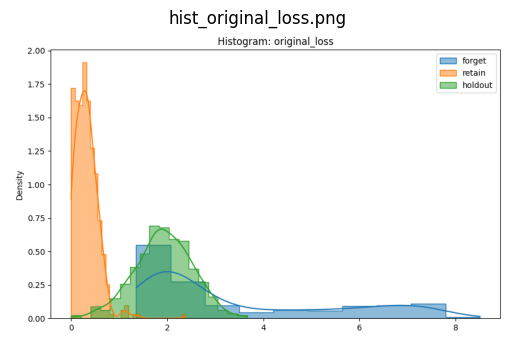

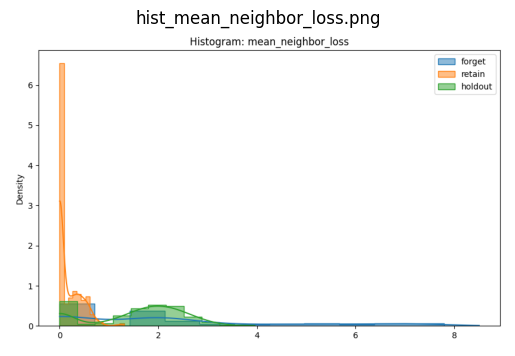

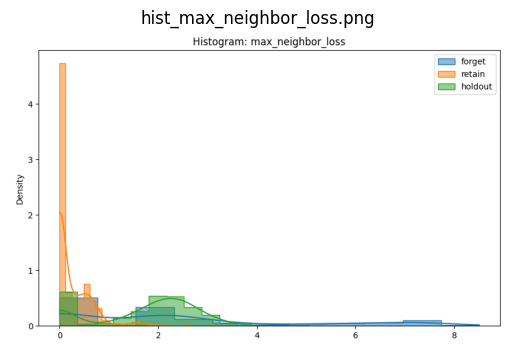

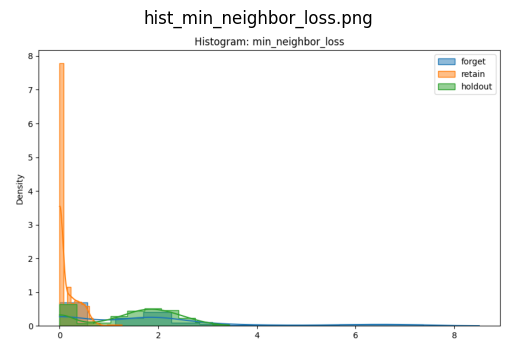

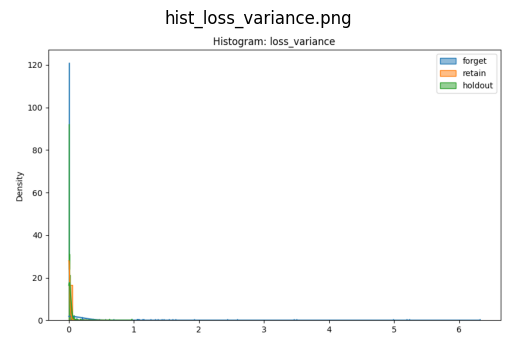

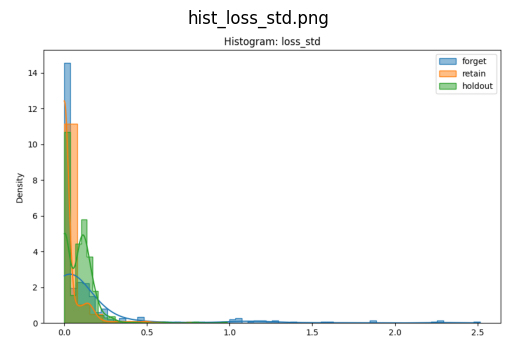

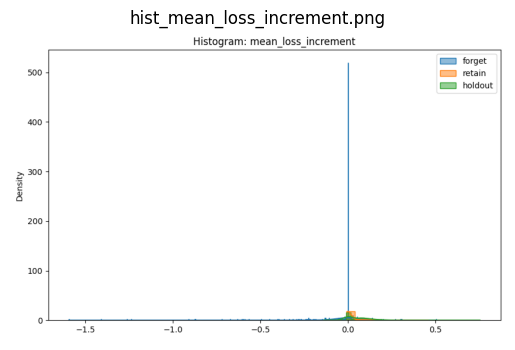

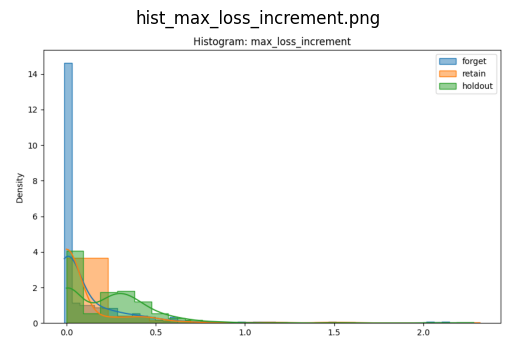

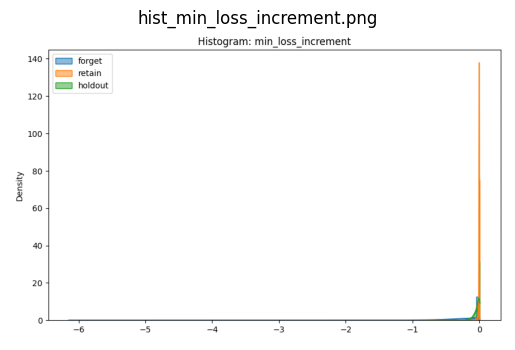

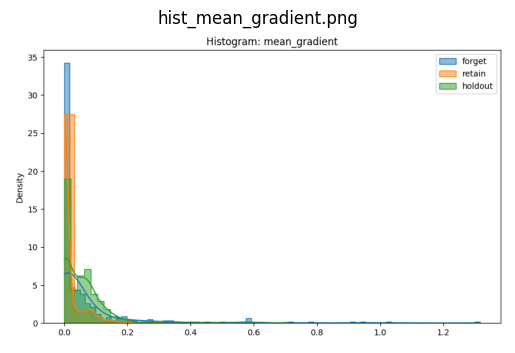

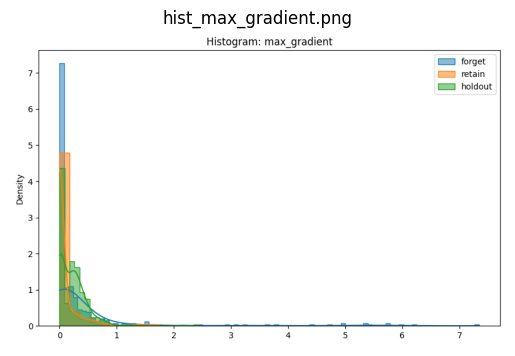

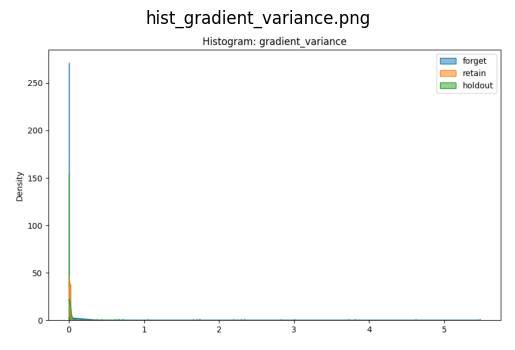

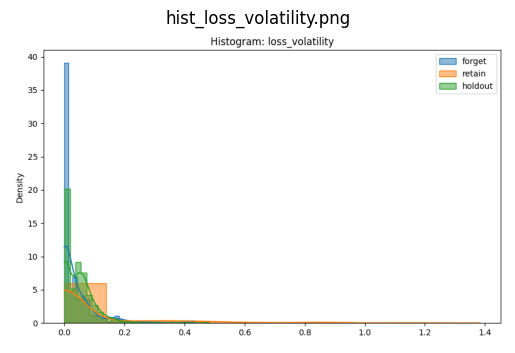

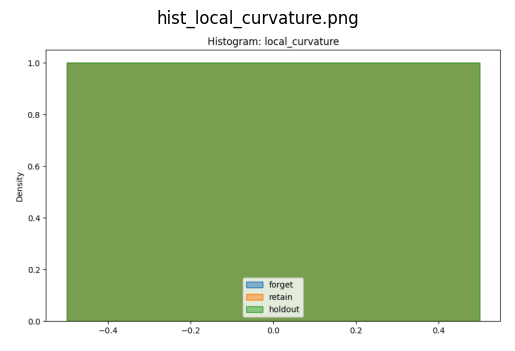

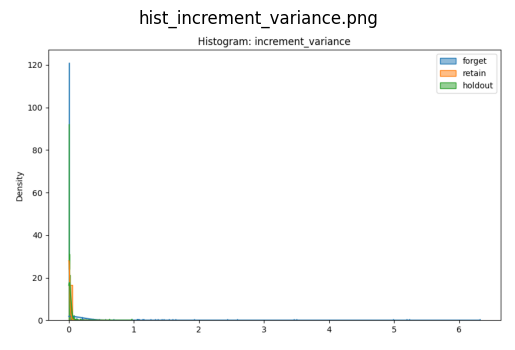

In [61]:
# Create loss landscape visualization plots
plots_base_dir = "tofu_loss_landscape_plots"
os.makedirs(plots_base_dir, exist_ok=True)

print("Creating loss landscape plots...")
plots = eval_with_ILL.plot_landscape_results_from_features(features_dict, plot_base_dir=plots_base_dir)

# Display histogram plots
print("Displaying histograms of loss landscape features...")
eval_with_ILL.show_plots(plots, ['hist'])

Training predictors for TOFU dataset classification...

=== TOFU Classification Results ===
Logistic Regression ACCURACY: 0.787
Random Forest ACCURACY: 0.787

Logistic Regression F1: 0.783
Random Forest F1: 0.786

Logistic Regression ROC_AUC: 0.926
Random Forest ROC_AUC: 0.911

Creating classification visualization plots...


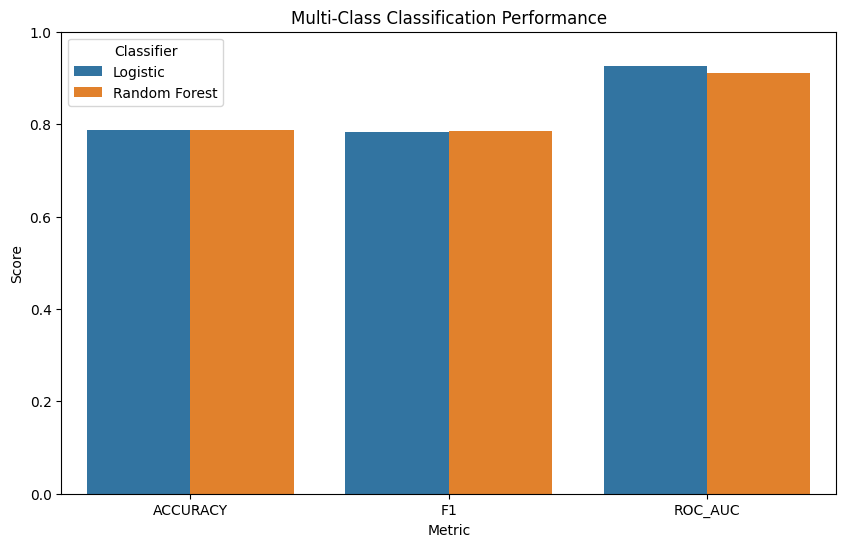

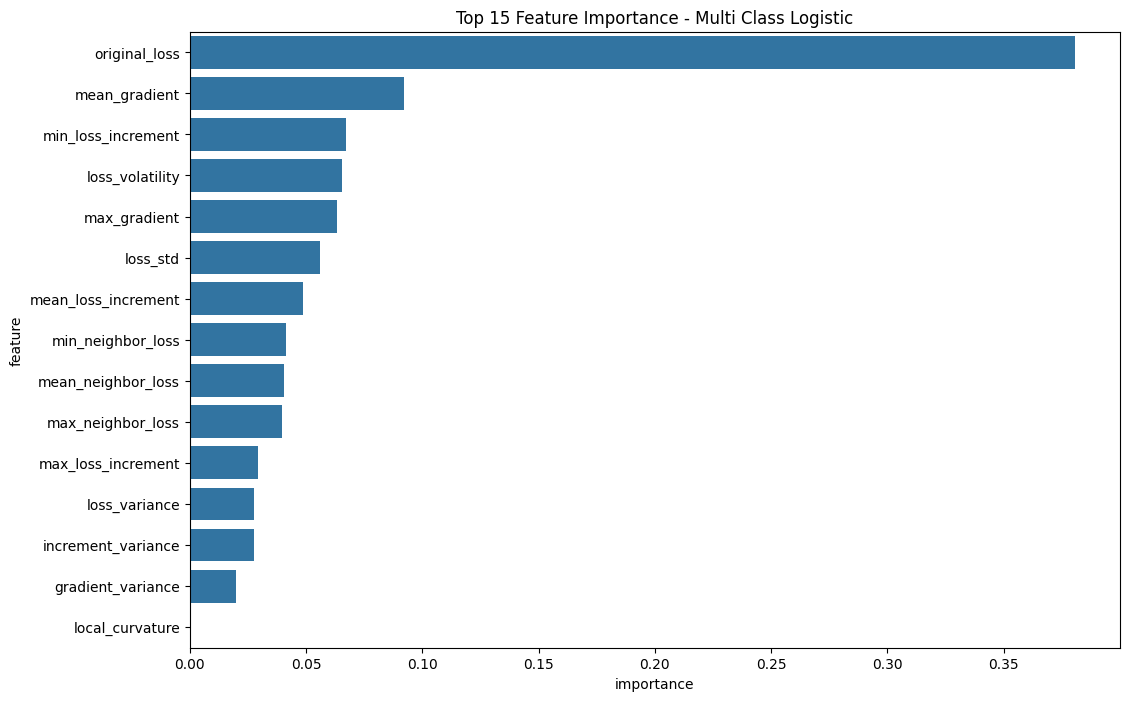

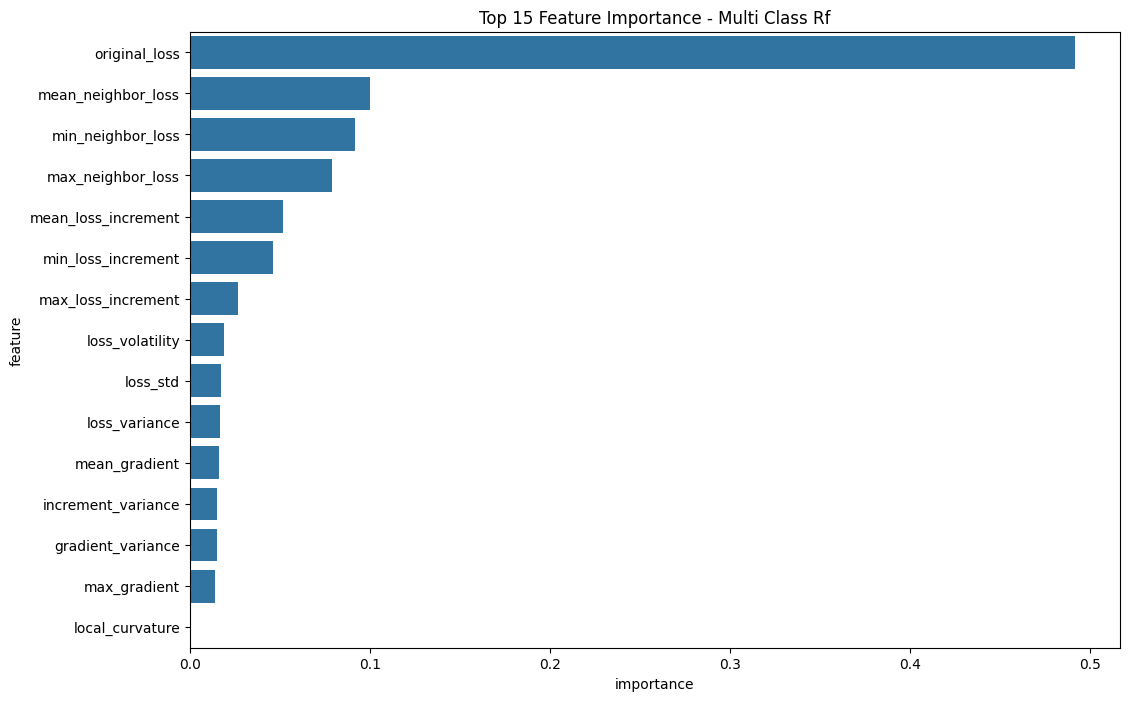

In [62]:
# Train predictors to distinguish between TOFU datasets
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# Get feature labels from the features dictionary
features_labels = features_dict['forget']['features_names']

print("Training predictors for TOFU dataset classification...")
# Train predictors using normalized tensors
results, feature_importance_results = eval_with_ILL.train_predictors(
    retain_t=norm_retain_tensor,
    holdout_t=norm_holdout_tensor,
    features_labels=features_labels,
    forget_t=norm_forget_tensor
)

print("\n=== TOFU Classification Results ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    print(f"Logistic Regression {metric.upper()}: {results['multi_class']['logistic'][metric]:.3f}")
    print(f"Random Forest {metric.upper()}: {results['multi_class']['random_forest'][metric]:.3f}")
    print()

# Create classification plots
print("Creating classification visualization plots...")
classification_plots = eval_with_ILL.plot_classification_results(results, feature_importance_results)

Creating confusion matrices...


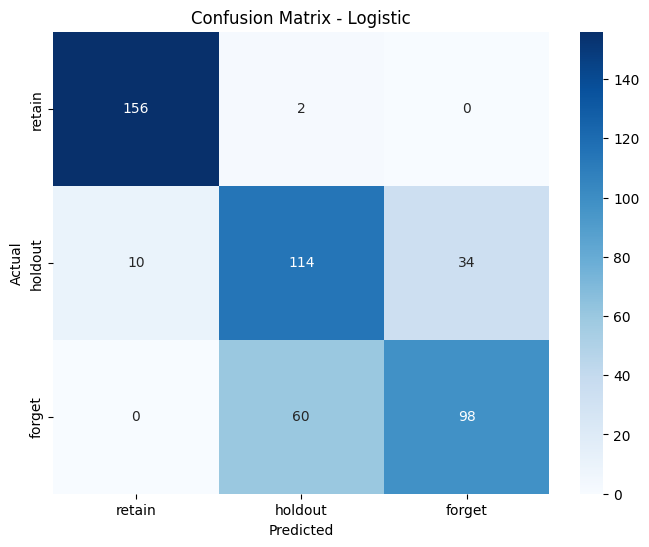

\n=== Classification Report - Logistic ===
              precision    recall  f1-score   support

      retain       0.94      0.99      0.96       158
     holdout       0.65      0.72      0.68       158
      forget       0.74      0.62      0.68       158

    accuracy                           0.78       474
   macro avg       0.78      0.78      0.77       474
weighted avg       0.78      0.78      0.77       474



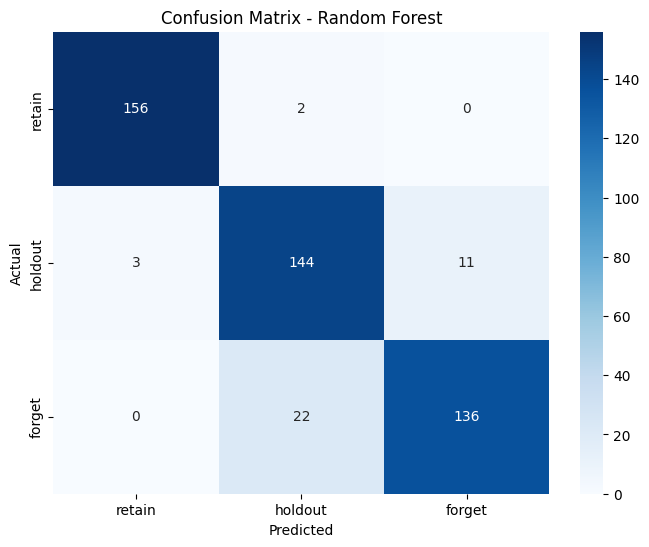

\n=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

      retain       0.98      0.99      0.98       158
     holdout       0.86      0.91      0.88       158
      forget       0.93      0.86      0.89       158

    accuracy                           0.92       474
   macro avg       0.92      0.92      0.92       474
weighted avg       0.92      0.92      0.92       474

Analyzing prediction confidence...


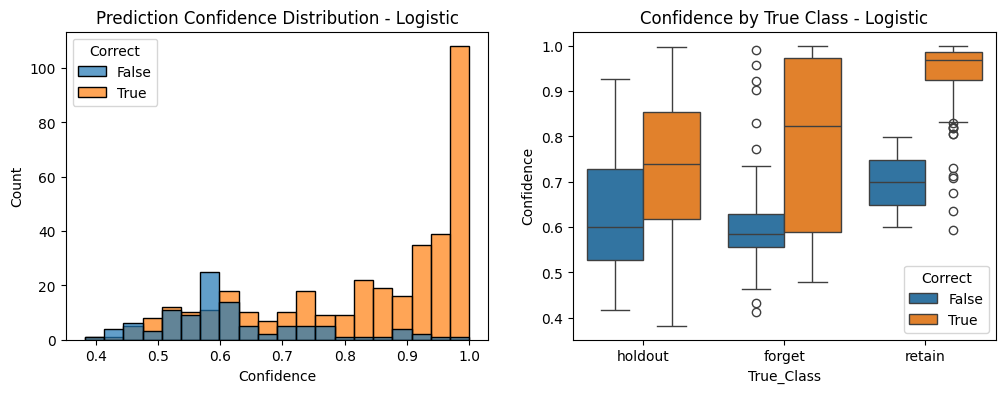

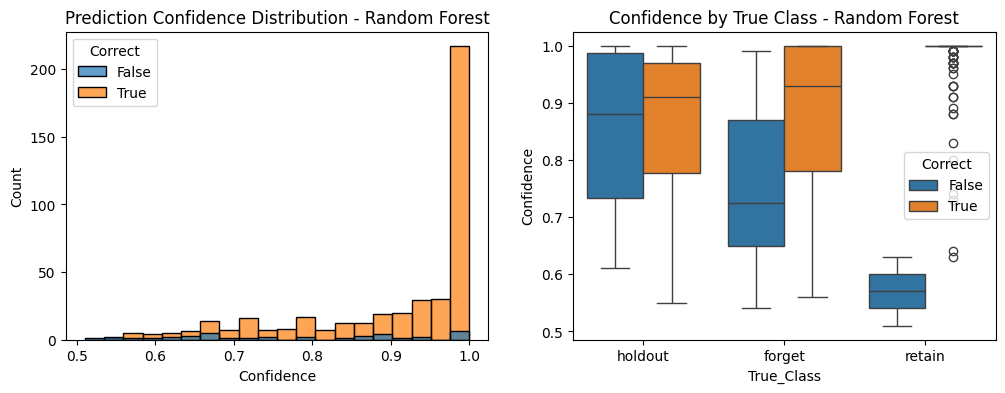

Generating ROC curves...


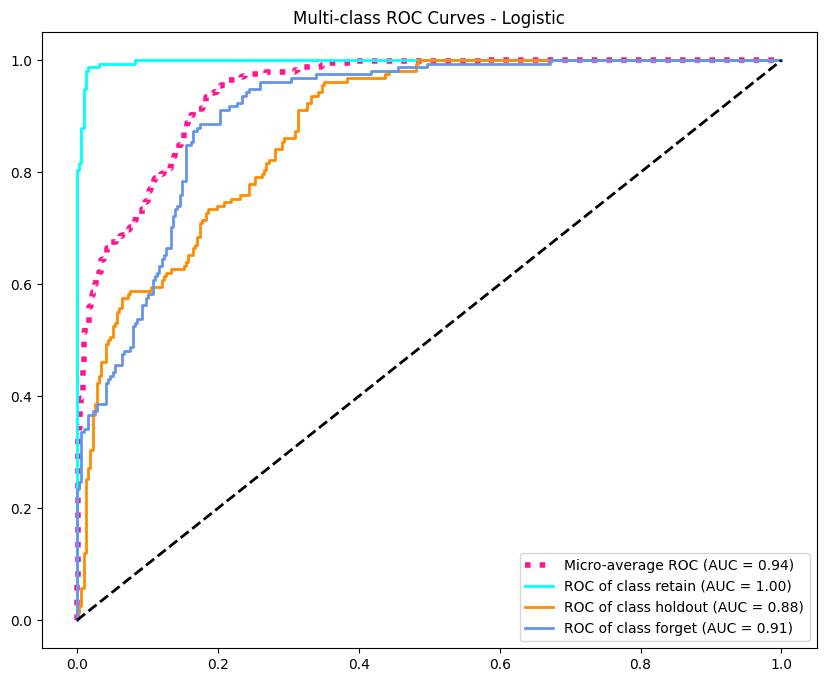

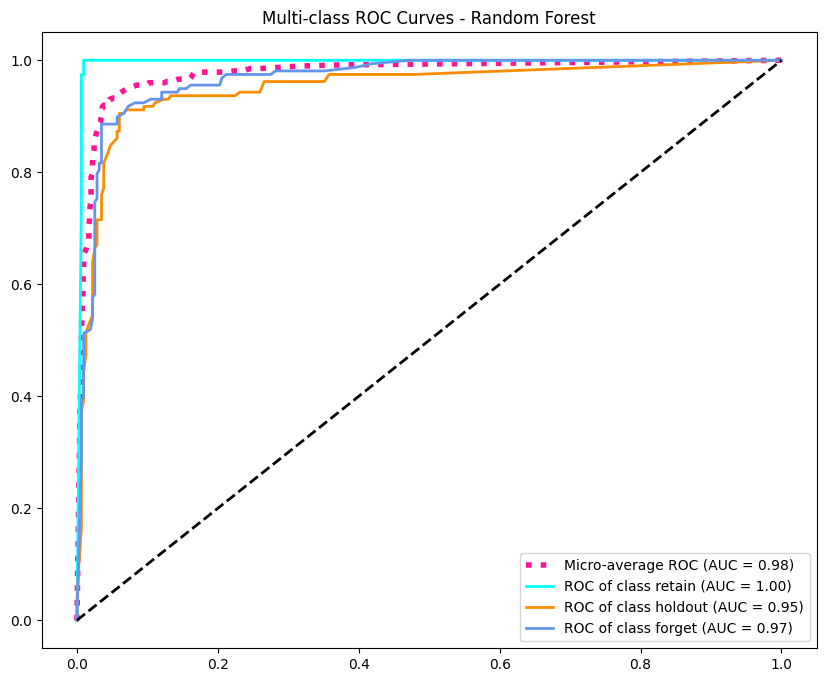


=== Summary ===
Classification analysis completed for TOFU datasets!
Generated plots show:
- Performance comparison between classifiers
- Feature importance for distinguishing forget/retain/holdout data
- Confusion matrices showing classification accuracy
- ROC curves for multi-class classification
- Prediction confidence analysis


In [63]:
# Display confusion matrices and ROC curves
print("Creating confusion matrices...")
eval_with_ILL.plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("Analyzing prediction confidence...")
eval_with_ILL.analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("Generating ROC curves...")
eval_with_ILL.plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("\n=== Summary ===")
print("Classification analysis completed for TOFU datasets!")
print("Generated plots show:")
print("- Performance comparison between classifiers")
print("- Feature importance for distinguishing forget/retain/holdout data")
print("- Confusion matrices showing classification accuracy")
print("- ROC curves for multi-class classification")
print("- Prediction confidence analysis")

In [64]:
print(f"{comparison_results=}")

comparison_results={'logistic': {'accuracy': 0.7869198312236287, 'f1': 0.6130268199233716, 'roc_auc': 0.8888799871815414, 'model': LogisticRegression(max_iter=300, random_state=42)}, 'random_forest': {'accuracy': 0.8122362869198312, 'f1': 0.7119741100323624, 'roc_auc': 0.886957218394488, 'model': RandomForestClassifier(random_state=42)}}


In [65]:
binary_results

{'holdout_vs_all': {'logistic': {'accuracy': 0.7573839662447257,
   'f1': 0.5660377358490566,
   'roc_auc': 0.8242669443999359,
   'model': LogisticRegression(max_iter=300, random_state=42)},
  'random_forest': {'accuracy': 0.7974683544303798,
   'f1': 0.7055214723926381,
   'roc_auc': 0.857985499118731,
   'model': RandomForestClassifier(random_state=42)}},
 'forget_vs_all': {'logistic': {'accuracy': 0.7869198312236287,
   'f1': 0.6130268199233716,
   'roc_auc': 0.8888799871815414,
   'model': LogisticRegression(max_iter=300, random_state=42)},
  'random_forest': {'accuracy': 0.8122362869198312,
   'f1': 0.7119741100323624,
   'roc_auc': 0.886957218394488,
   'model': RandomForestClassifier(random_state=42)}}}

Running binary comparisons between TOFU dataset pairs...


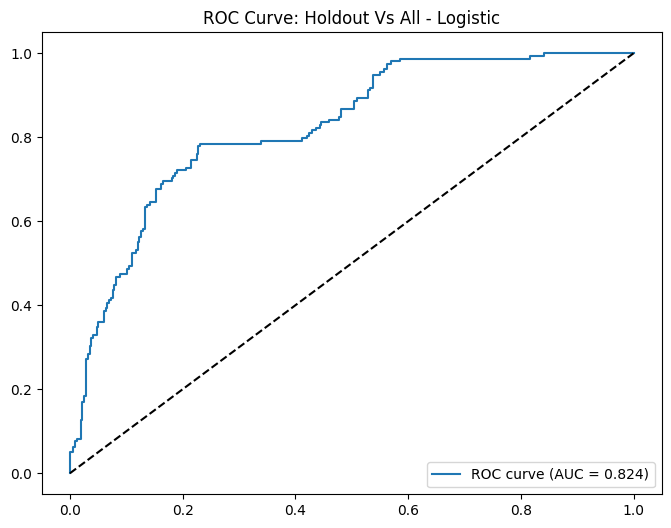

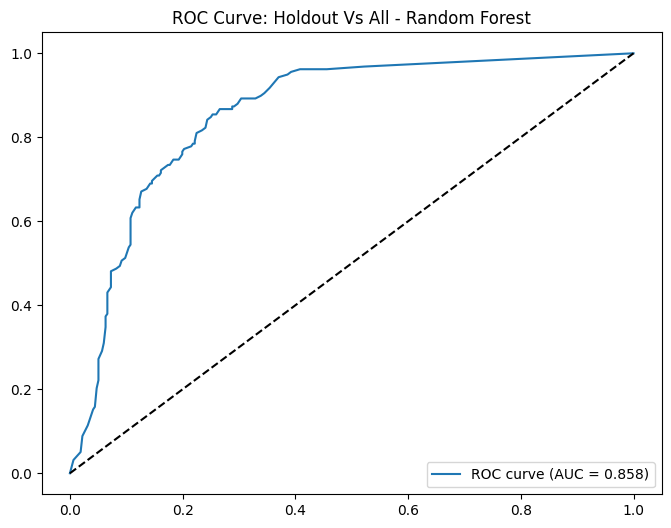

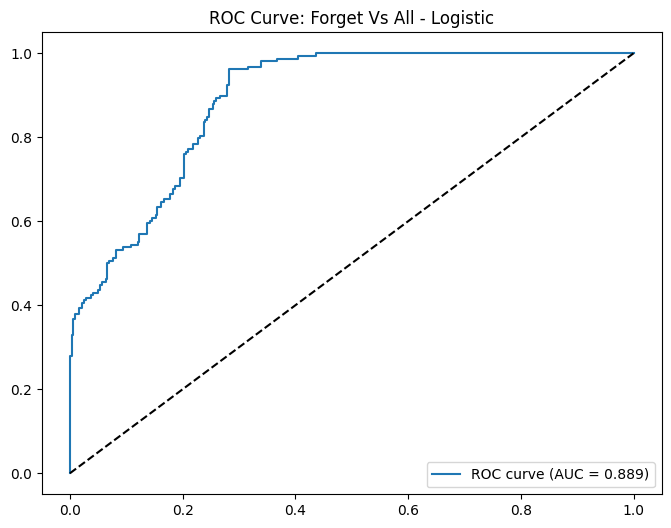

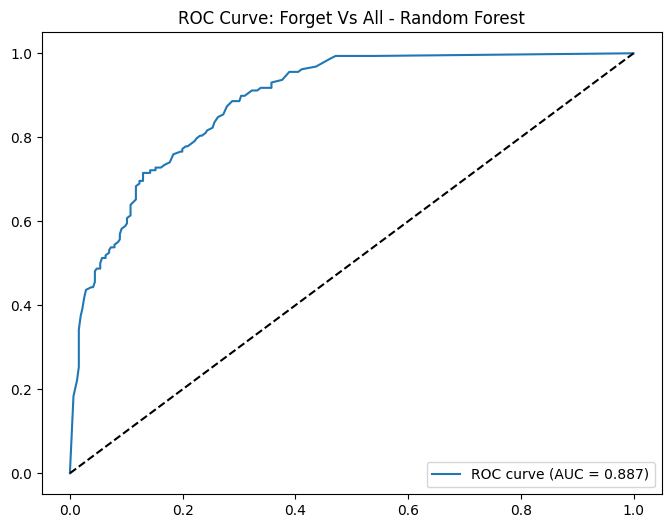

Creating comprehensive analysis summary...


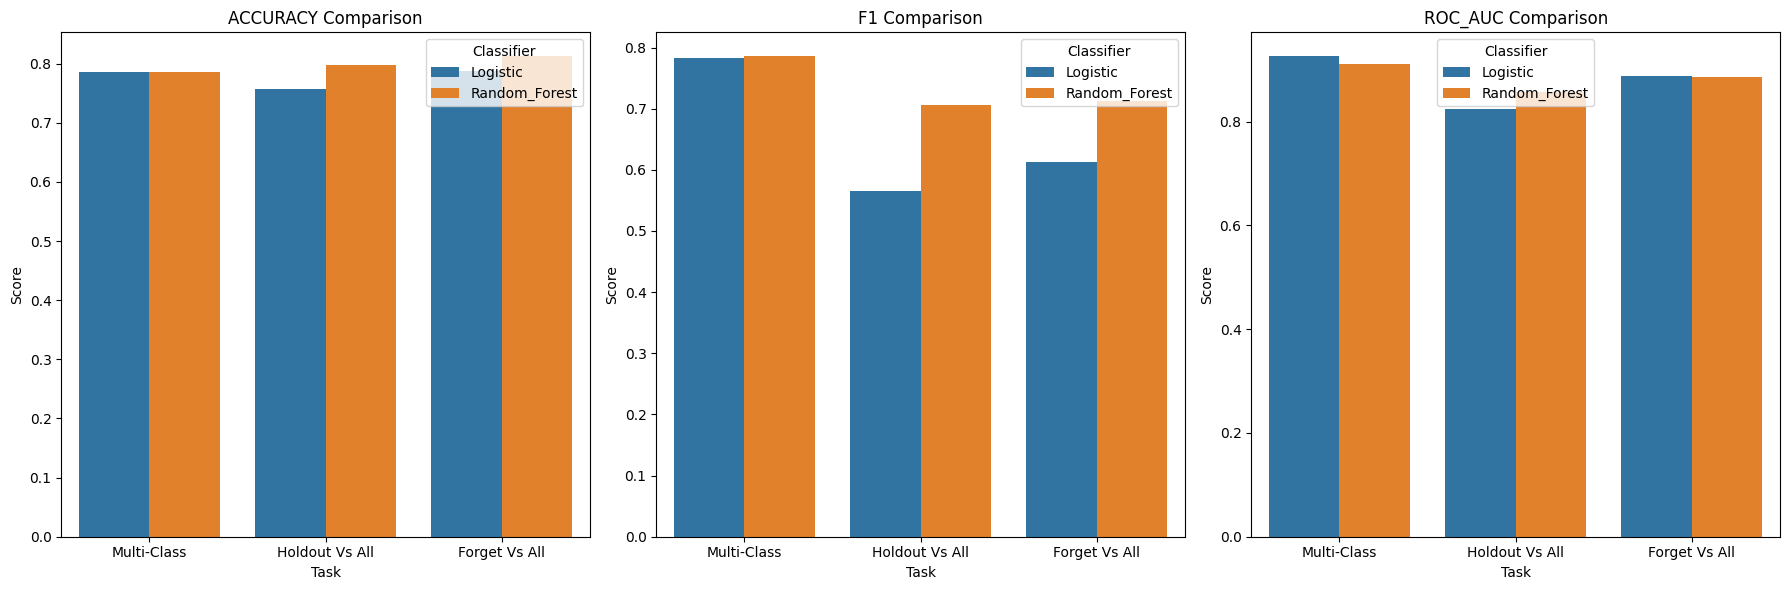


=== Binary Classification Results ===

Holdout Vs Vs Vs All:
  Accuracy: 0.757
  F1 Score: 0.566
  ROC AUC: 0.824

Holdout Vs Vs Vs All:
  Accuracy: 0.797
  F1 Score: 0.706
  ROC AUC: 0.858

Forget Vs Vs Vs All:
  Accuracy: 0.787
  F1 Score: 0.613
  ROC AUC: 0.889

Forget Vs Vs Vs All:
  Accuracy: 0.812
  F1 Score: 0.712
  ROC AUC: 0.887


In [66]:
# Run binary comparisons between dataset pairs
print("Running binary comparisons between TOFU dataset pairs...")
binary_results, binary_feature_importance = eval_with_ILL.train_binary_comparisons(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Create comprehensive summary
print("Creating comprehensive analysis summary...")
comprehensive_plots = eval_with_ILL.create_comprehensive_summary(
    results, binary_results, feature_importance_results, binary_feature_importance
)

print("\n=== Binary Classification Results ===")
for comparison_name, comparison_results in binary_results.items():
    for classifier_type, c_comparison_results in comparison_results.items():
        print(f"\n{comparison_name.replace('_', ' vs ').title()}:")
        print(f"  Accuracy: {c_comparison_results['accuracy']:.3f}")
        print(f"  F1 Score: {c_comparison_results['f1']:.3f}")
        print(f"  ROC AUC: {c_comparison_results['roc_auc']:.3f}")

# Input Loss Landscape (ILL) Discriminative Analysis for TOFU Dataset

This section provides specialized methods to analyze and distinguish between **forget**, **retain**, and **holdout** datasets from the TOFU (Task of Fictitious Unlearning) benchmark using Input Loss Landscape features.

## TOFU Dataset Overview:
- **Forget**: Fictitious author information that should be "forgotten" (1% subset)
- **Retain**: Fictitious author information that should be retained (99% subset)  
- **Holdout**: Real author information for evaluation

## ILL Features Used:
- **Loss-based**: `original_loss`, `mean_neighbor_loss`, `max_neighbor_loss`, `min_neighbor_loss`
- **Variance-based**: `loss_variance`, `loss_std`, `increment_variance`
- **Gradient-based**: `mean_gradient`, `max_gradient`, `gradient_variance`
- **Landscape properties**: `loss_volatility`, `local_curvature`
- **Increment-based**: `mean_loss_increment`, `max_loss_increment`, `min_loss_increment`
- **Embeddings**: Sentence embeddings for semantic analysis

The goal is to identify which ILL features are most discriminative for distinguishing between the TOFU dataset types and understand the loss landscape characteristics of machine unlearning scenarios.

In [67]:
# Advanced Statistical Analysis for TOFU ILL Features
from scipy.stats import wasserstein_distance, ks_2samp, entropy, skew, kurtosis
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Try to import UMAP, install if not available
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP available for manifold analysis")
except ImportError:
    print("UMAP not available. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

# Compute statistical distances between TOFU datasets
print("Computing statistical distances between TOFU datasets...")
stat_distances = eval_with_ILL.compute_statistical_distances(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

print("Statistical distance computation completed!")

UMAP available for manifold analysis
Computing statistical distances between TOFU datasets...
Statistical distance computation completed!


Plotting statistical distances heatmap...


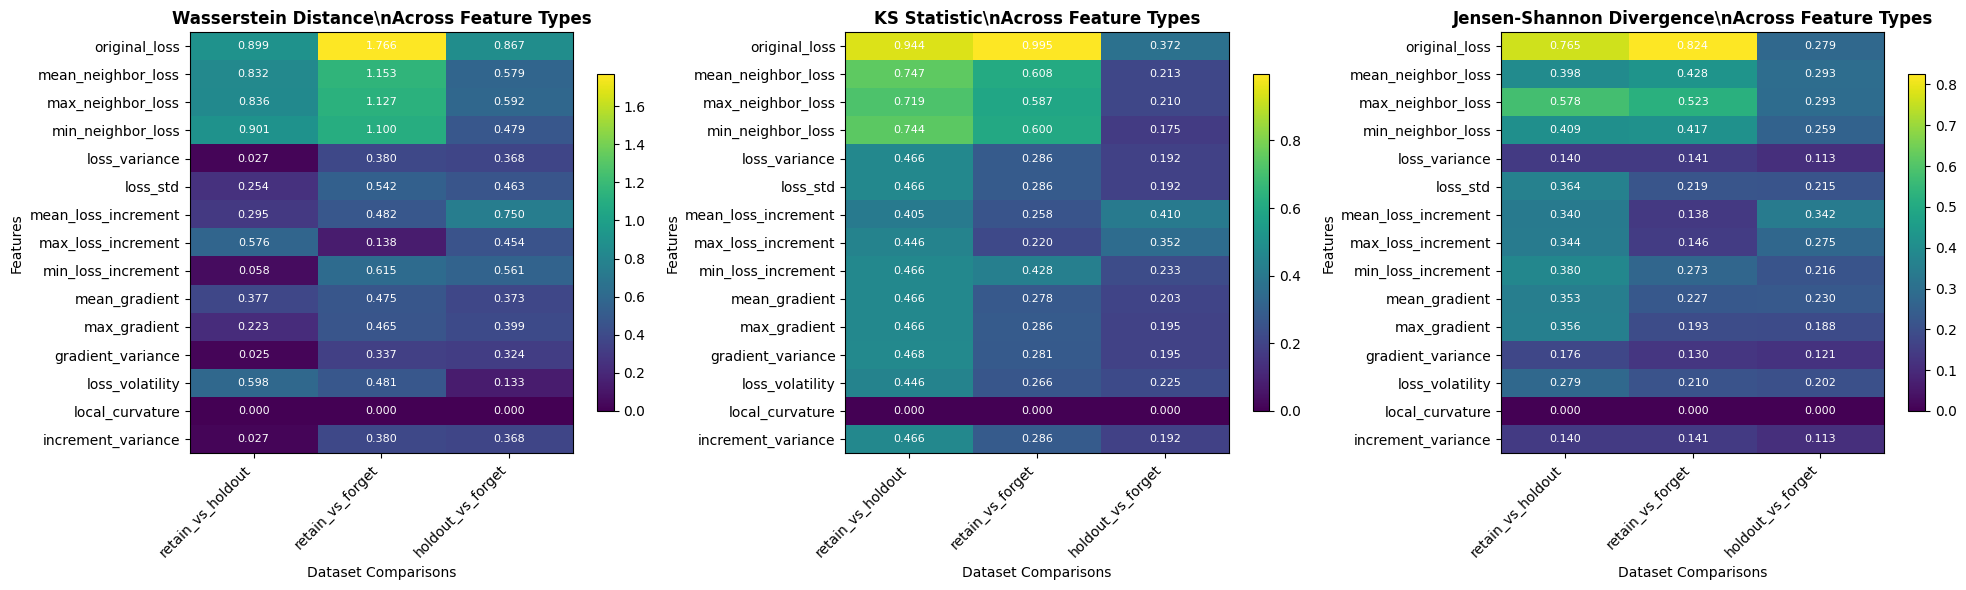

Analyzing manifold structures for TOFU datasets...
Computing PCA embedding...
Computing TSNE embedding...
Computing Isomap embedding...
Computing UMAP embedding...


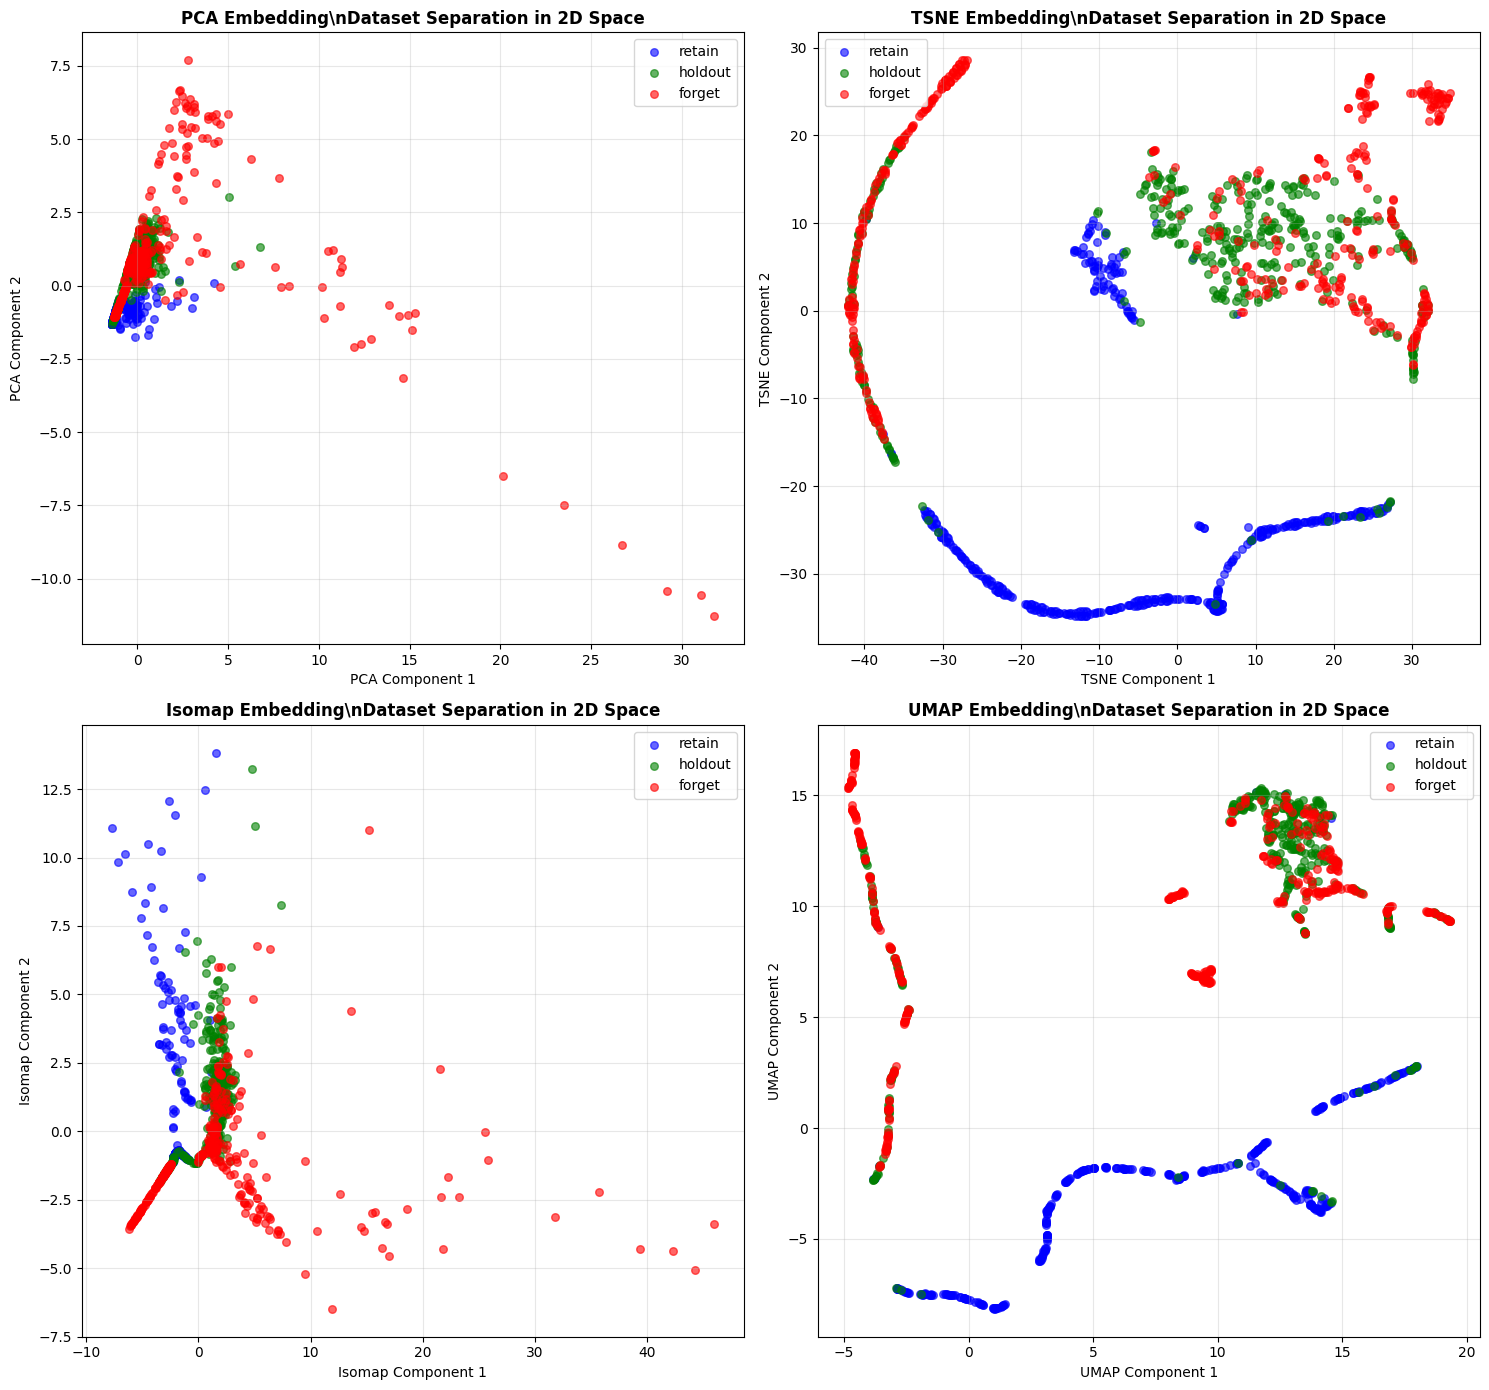

Manifold analysis shows how well TOFU datasets can be separated in reduced dimensions
Look for distinct clusters in the plots - well-separated clusters indicate
that the datasets have different loss landscape characteristics


In [68]:
# Visualize statistical distances between TOFU datasets
print("Plotting statistical distances heatmap...")
eval_with_ILL.plot_statistical_distances(stat_distances, features_labels)

# Perform manifold analysis to visualize dataset separability
print("Analyzing manifold structures for TOFU datasets...")
manifold_results = eval_with_ILL.compare_manifold_structures(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor
)

print("Manifold analysis shows how well TOFU datasets can be separated in reduced dimensions")
print("Look for distinct clusters in the plots - well-separated clusters indicate")
print("that the datasets have different loss landscape characteristics")

In [69]:
# Run transfer analysis
print("Analyzing prediction transfer...")
transfer_results = eval_with_ILL.analyze_prediction_transfer(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing prediction transfer...


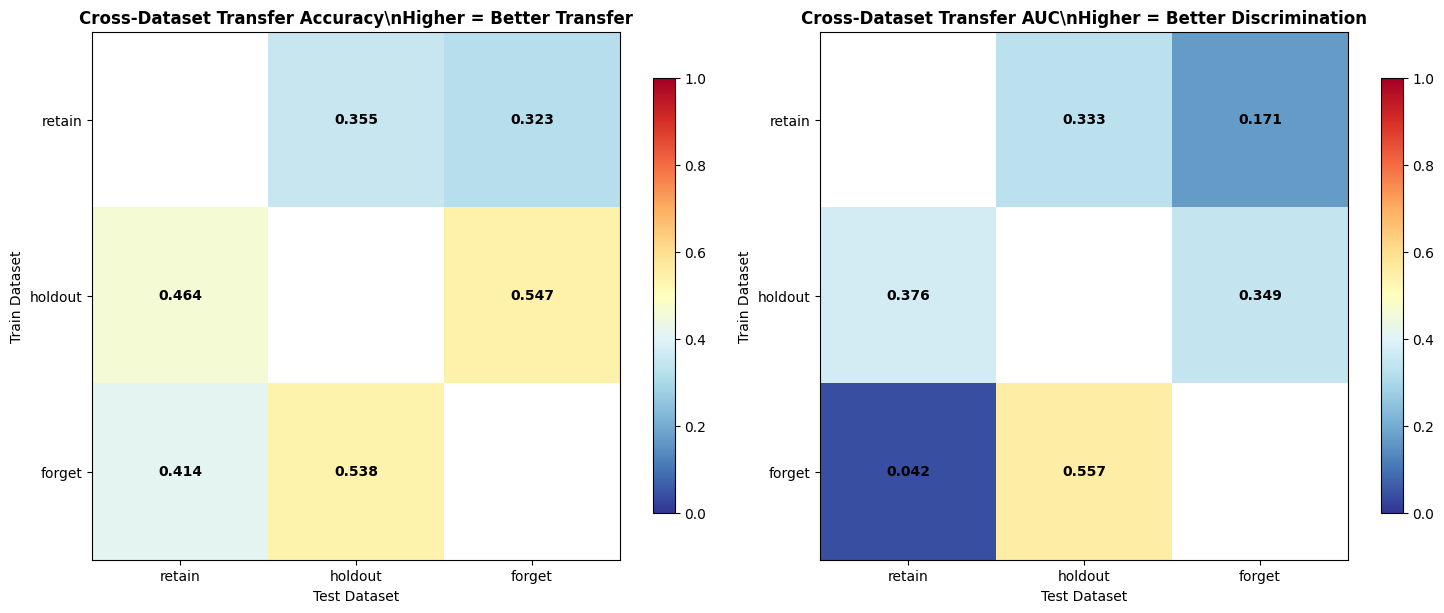

In [70]:
# Plot transfer results
eval_with_ILL.plot_transfer_results(transfer_results)

Analyzing ILL feature discrimination for TOFU unlearning scenarios...
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.793 (+/- 0.086)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. original_loss: 0.4788
2. mean_neighbor_loss: 0.1031
3. min_neighbor_loss: 0.0957
4. max_neighbor_loss: 0.0787
5. mean_loss_increment: 0.0480
Creating ILL discrimination visualization...


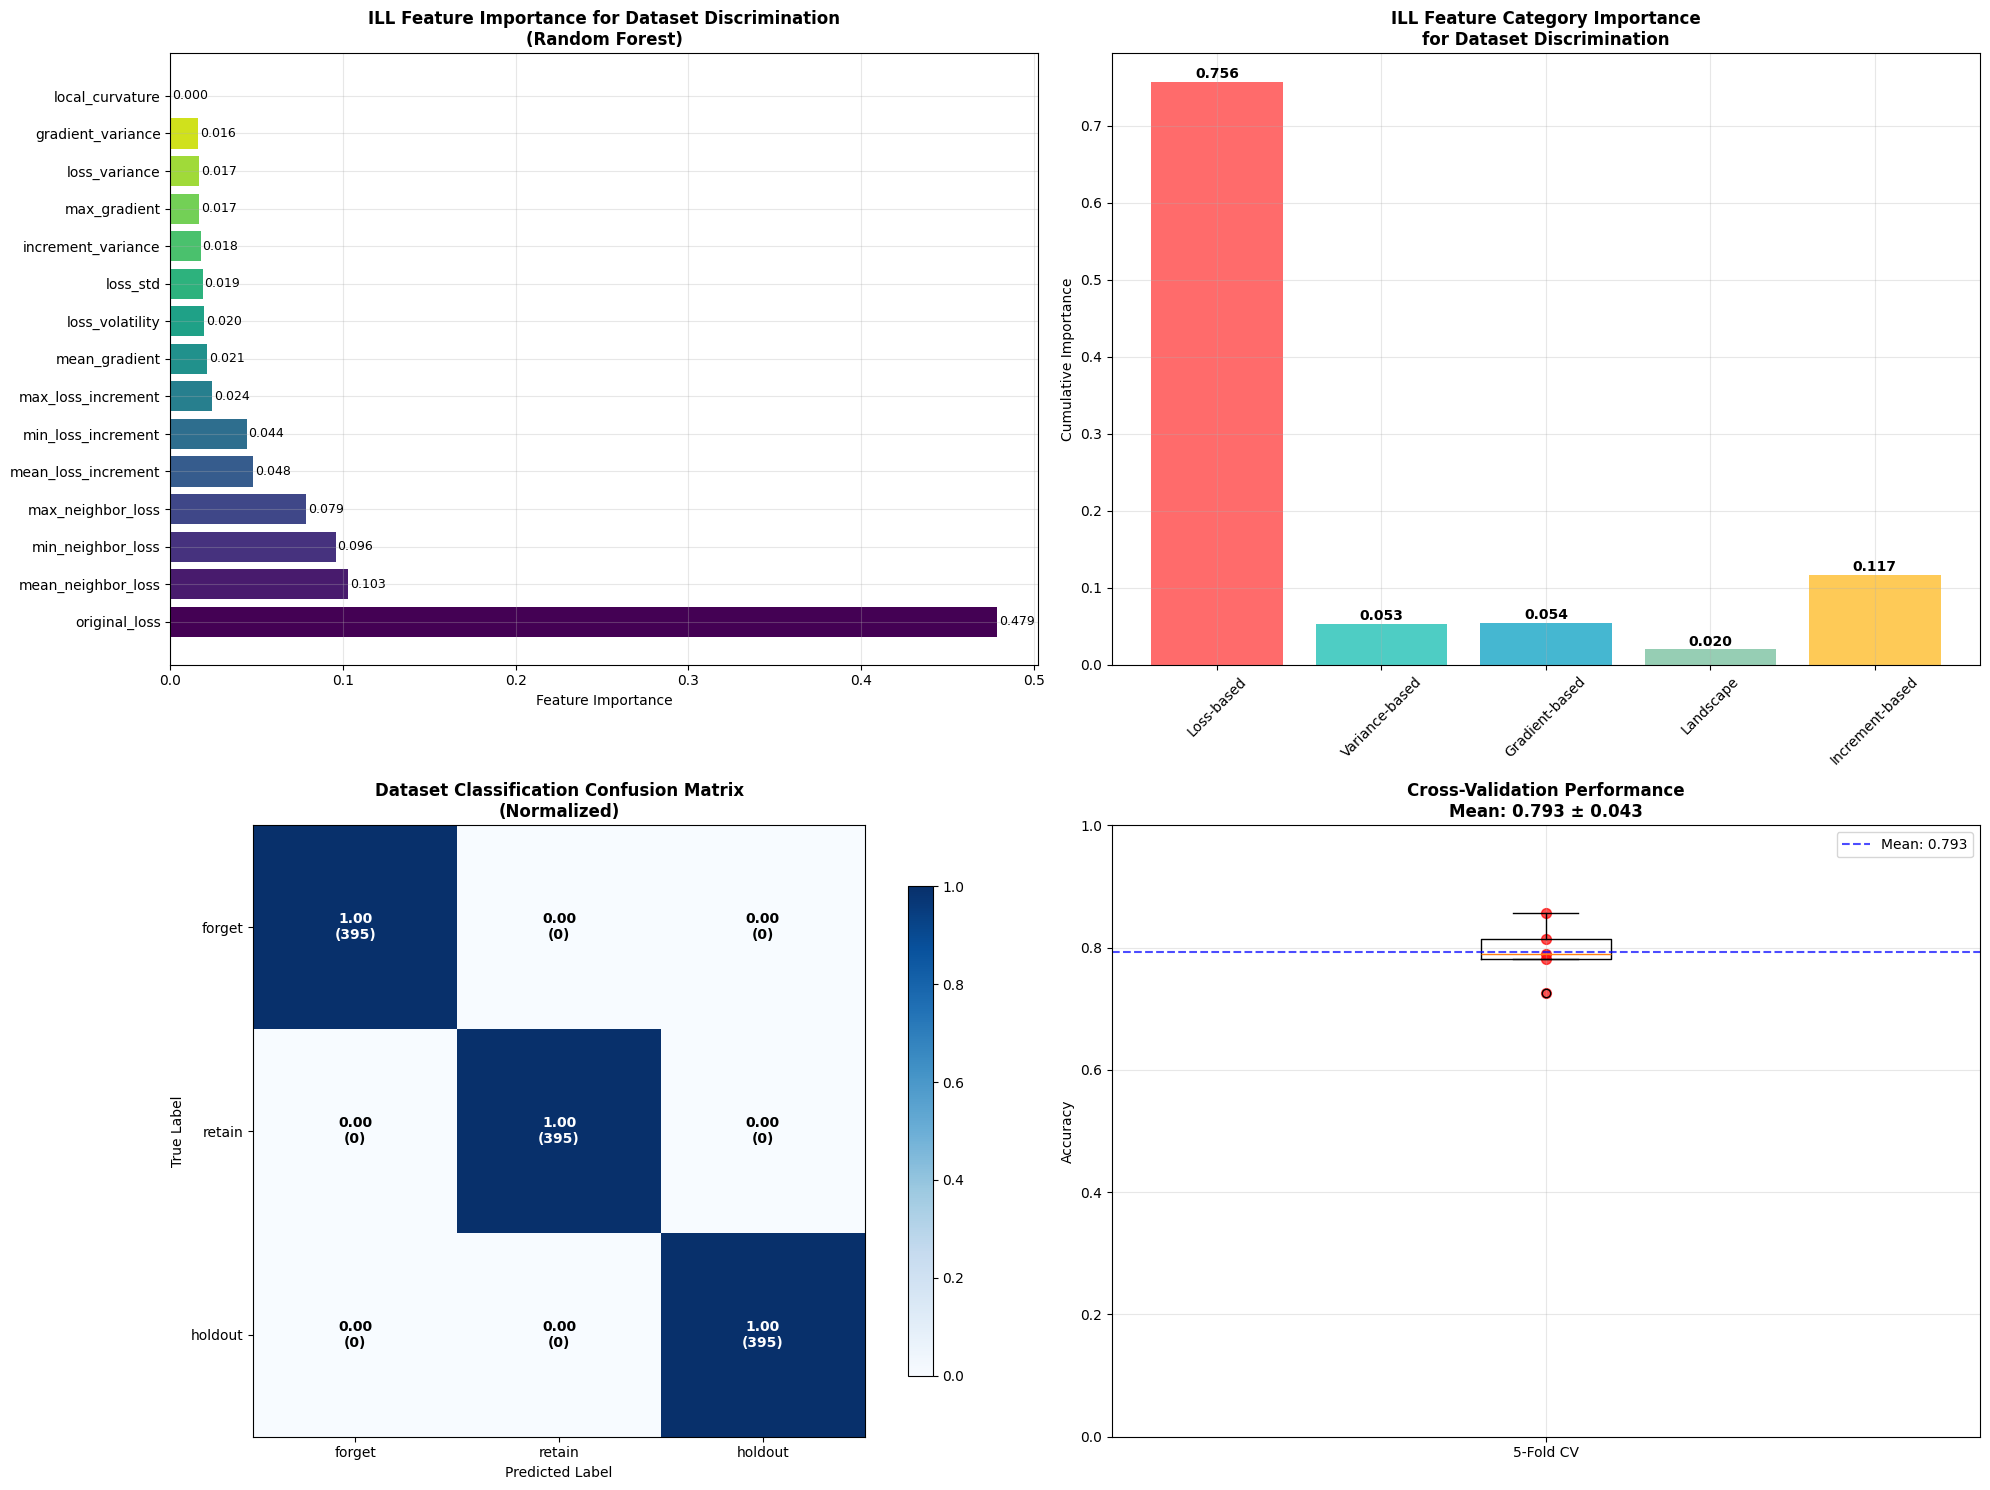

Analyzing loss landscape topology for TOFU machine unlearning...
LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS

LOSS FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 1.402
    Max effect size: 2.170
  forget vs holdout:
    Average effect size: 0.448
    Max effect size: 1.030
  retain vs holdout:
    Average effect size: 2.303
    Max effect size: 3.480

VARIANCE FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.368
    Max effect size: 0.469
  forget vs holdout:
    Average effect size: 0.284
    Max effect size: 0.297
  retain vs holdout:
    Average effect size: 0.314
    Max effect size: 0.606

GRADIENT FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.370
    Max effect size: 0.431
  forget vs holdout:
    Average effect size: 0.187
    Max effect size: 0.261
  retain vs holdout:
    Average effect size: 0.456
    Max effect size: 0.676

LANDSCAPE FEATURES:
---------

In [71]:
# Specialized ILL Discrimination Analysis for TOFU Unlearning
print("Analyzing ILL feature discrimination for TOFU unlearning scenarios...")

# Run ILL-specific discrimination analysis
ill_discrimination = eval_with_ILL.analyze_ill_feature_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Plot discrimination analysis results
print("Creating ILL discrimination visualization...")
eval_with_ILL.plot_ill_discrimination_analysis(ill_discrimination, features_labels)

# Analyze loss landscape topology for machine unlearning
print("Analyzing loss landscape topology for TOFU machine unlearning...")
topology_discrimination = eval_with_ILL.analyze_loss_landscape_topology_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Analyze decision boundaries in the loss landscape
print("Analyzing loss landscape boundaries for TOFU datasets...")
boundary_results = eval_with_ILL.analyze_loss_landscape_boundaries(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing pairwise discrimination between TOFU dataset combinations...
PAIRWISE DISCRIMINATION ANALYSIS

FORGET vs RETAIN:
-------------------------
Binary classification accuracy: 0.994 ± 0.004
Significant features: 13/15
Top 3 discriminative features:
  original_loss: Cohen's d = 2.170, p = 0.0000
  mean_neighbor_loss: Cohen's d = 1.170, p = 0.0000
  max_neighbor_loss: Cohen's d = 1.141, p = 0.0000

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.735 ± 0.055
Significant features: 12/15
Top 3 discriminative features:
  original_loss: Cohen's d = 1.030, p = 0.0000
  mean_loss_increment: Cohen's d = -0.671, p = 0.0000
  min_loss_increment: Cohen's d = -0.474, p = 0.0000

RETAIN vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.952 ± 0.017
Significant features: 14/15
Top 3 discriminative features:
  original_loss: Cohen's d = -3.480, p = 0.0000
  mean_neighbor_loss: Cohen's d = -1.946, p = 0.0000
  min_neighbor_loss: Cohen's d = -1.933

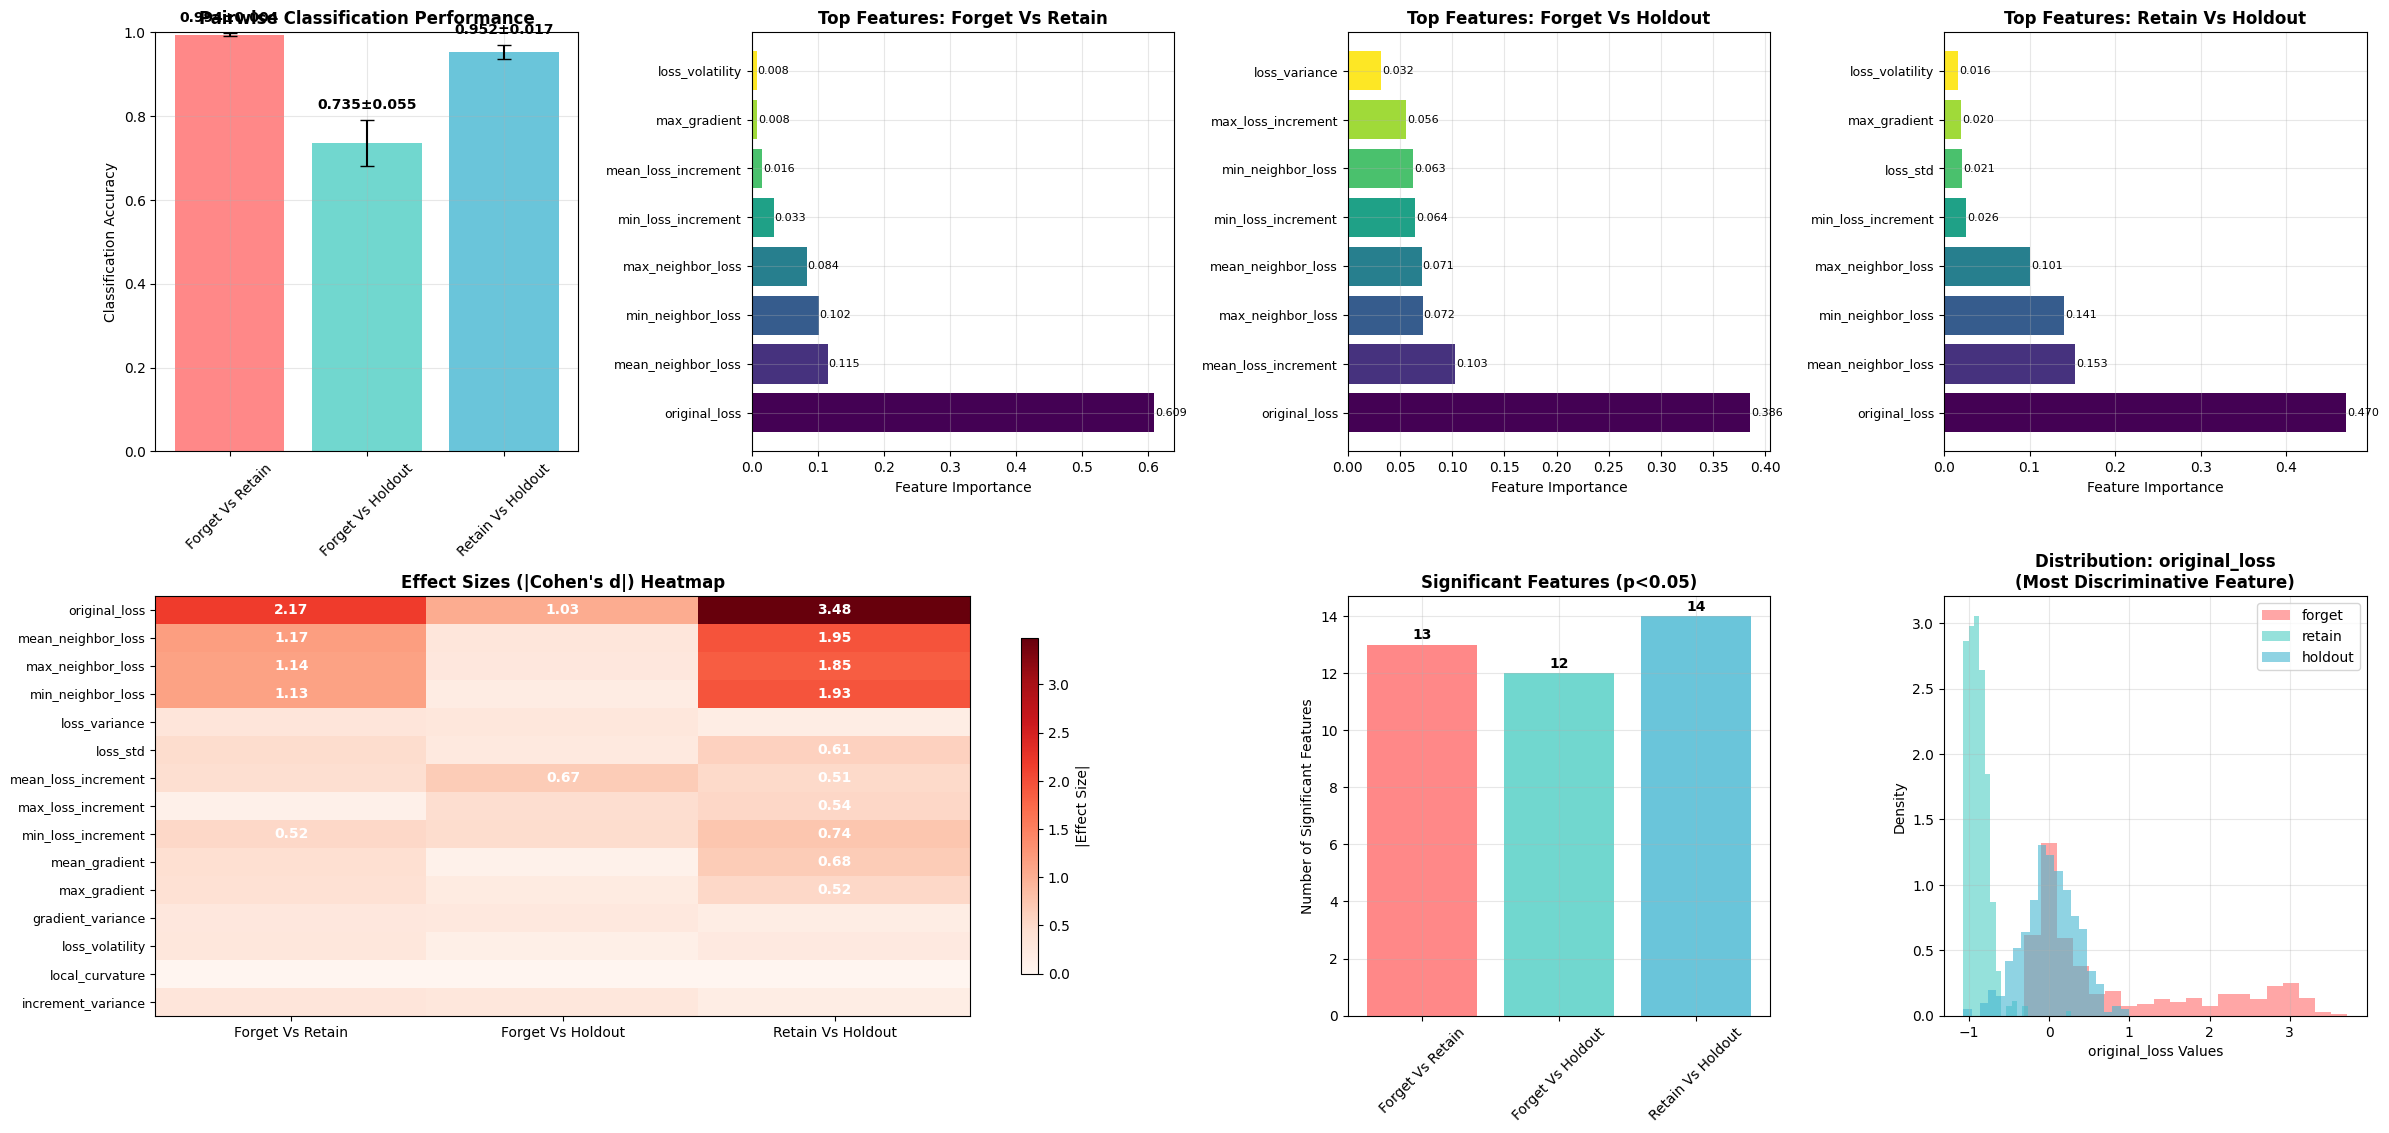


🎯 MOST DISCRIMINATIVE FEATURE FOR TOFU UNLEARNING: original_loss
   Average effect size across all dataset pairs: 2.227


In [72]:
# Pairwise Discrimination Analysis for TOFU Dataset Pairs
print("Analyzing pairwise discrimination between TOFU dataset combinations...")
pairwise_results = eval_with_ILL.analyze_pairwise_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Generate comprehensive pairwise discrimination plots and identify best features
print("Creating comprehensive pairwise discrimination results...")
best_discriminative_feature, feature_discrimination_scores = eval_with_ILL.plot_pairwise_discrimination_results(
    pairwise_results, features_labels, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor
)

print(f"\n🎯 MOST DISCRIMINATIVE FEATURE FOR TOFU UNLEARNING: {best_discriminative_feature}")
print(f"   Average effect size across all dataset pairs: {feature_discrimination_scores[best_discriminative_feature]:.3f}")

# This feature is most useful for distinguishing between forget/retain/holdout data in unlearning scenarios!

In [73]:
# Specialized Input Loss Landscape (ILL) Analysis Functions

def analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze loss landscape features by semantic categories relevant to ILL.
    """
    # Define feature categories for ILL analysis
    feature_categories = {
        'Base Loss': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variability': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    category_analysis = {}
    
    # Analyze each category
    for category, features in feature_categories.items():
        category_data = {}
        
        for dataset_name, tensor in datasets.items():
            category_features = []
            for feature in features:
                if feature in features_labels:
                    feat_idx = features_labels.index(feature)
                    category_features.append(tensor[:, feat_idx].numpy())
            
            if category_features:
                category_tensor = np.column_stack(category_features)
                
                # Compute category-level statistics
                category_data[dataset_name] = {
                    'mean_values': np.mean(category_tensor, axis=0),
                    'std_values': np.std(category_tensor, axis=0),
                    'category_mean': np.mean(category_tensor),
                    'category_std': np.std(category_tensor),
                    'feature_correlations': np.corrcoef(category_tensor.T),
                    'feature_names': [f for f in features if f in features_labels]
                }
        
        category_analysis[category] = category_data
    
    return category_analysis

# Run category analysis
print("Analyzing ILL features by semantic categories...")
category_analysis = analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Analyzing ILL features by semantic categories...


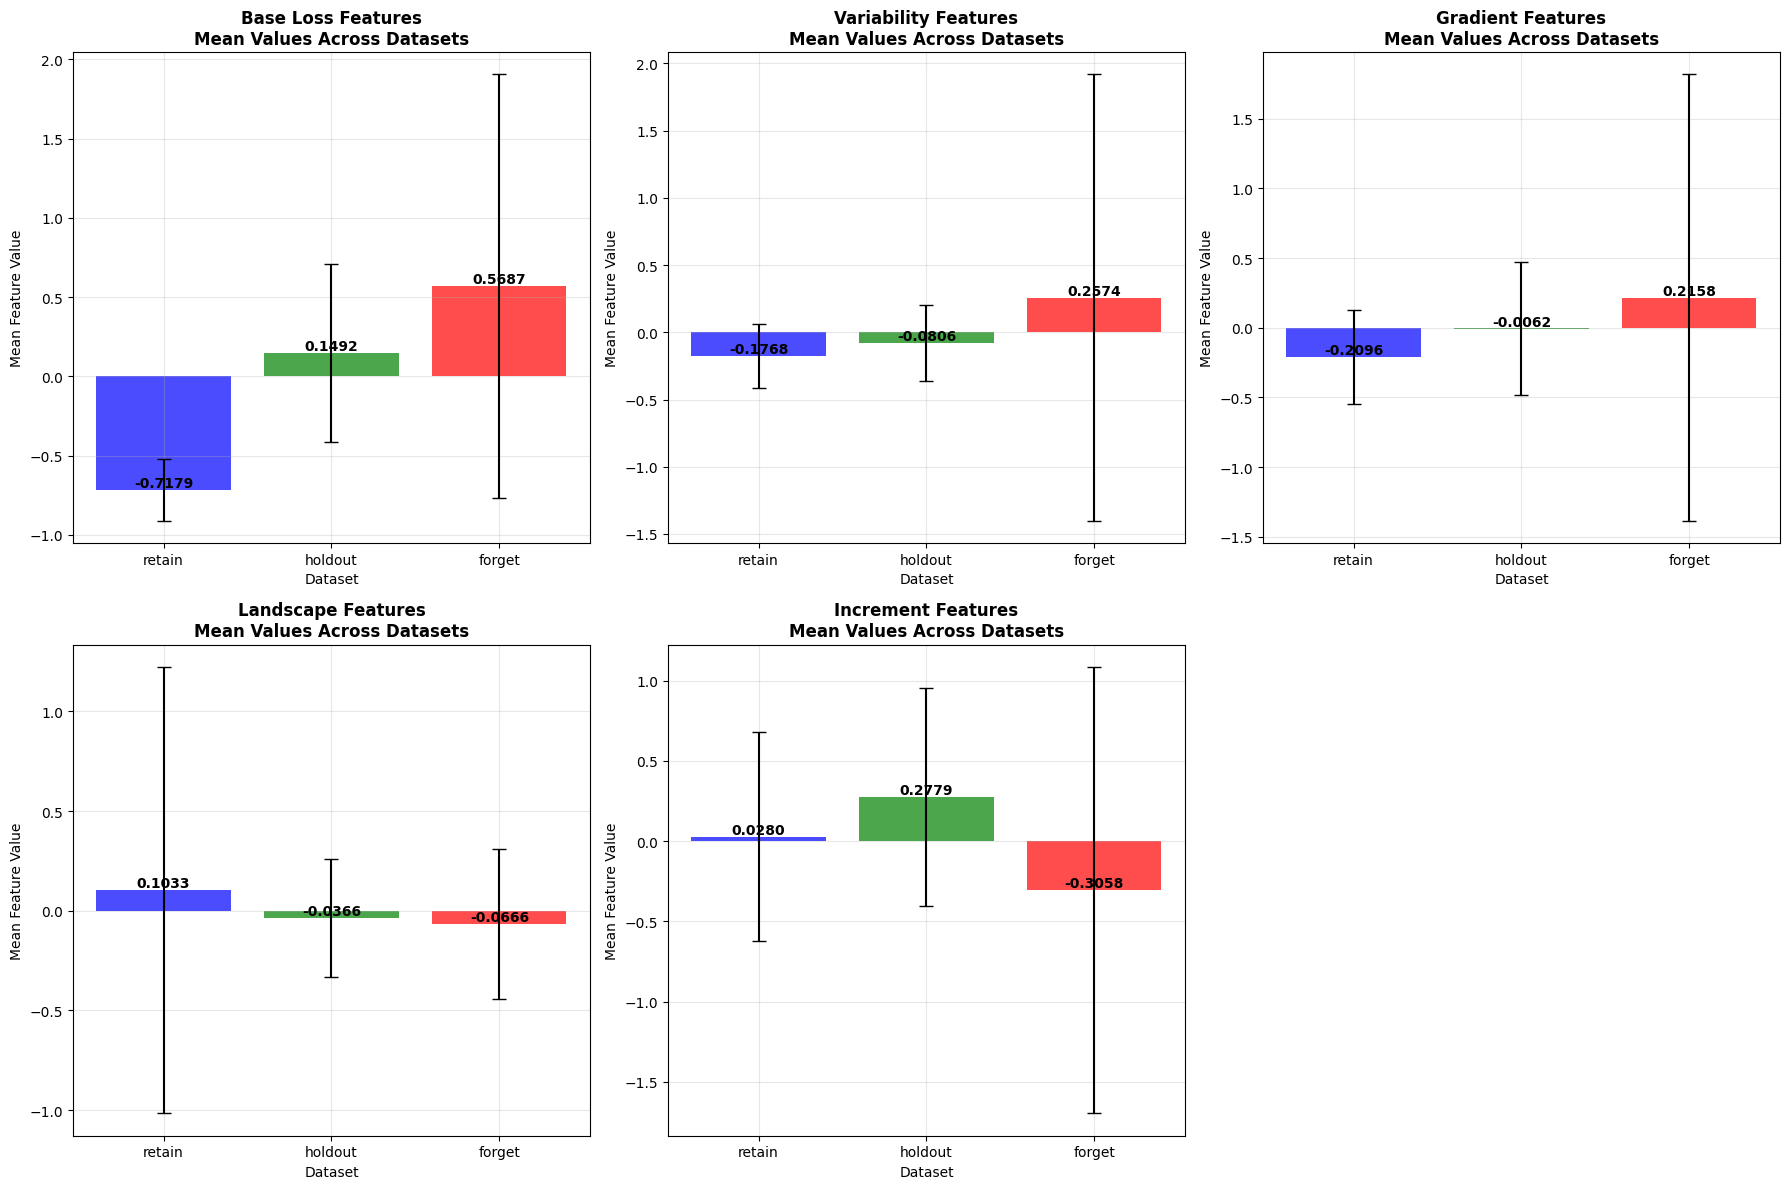

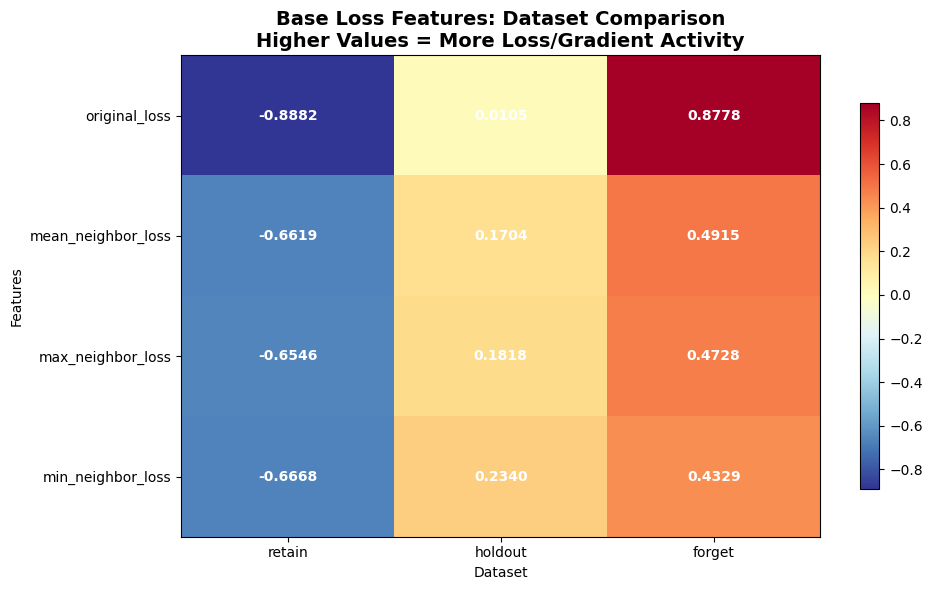

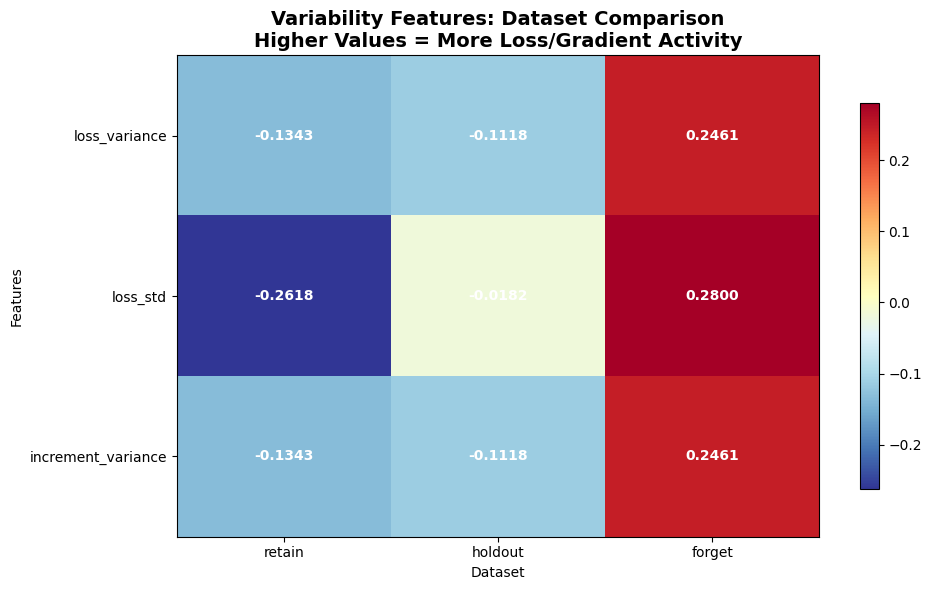

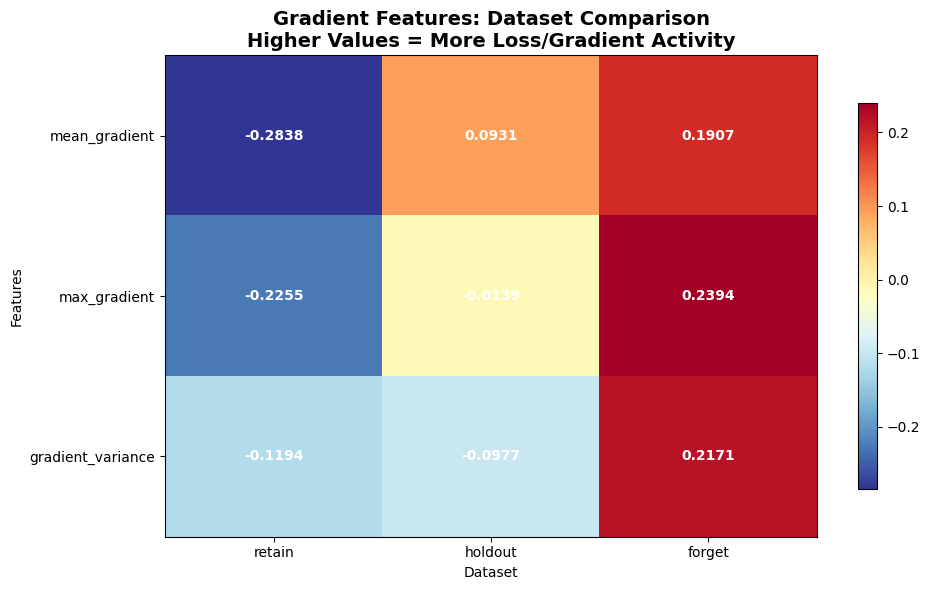

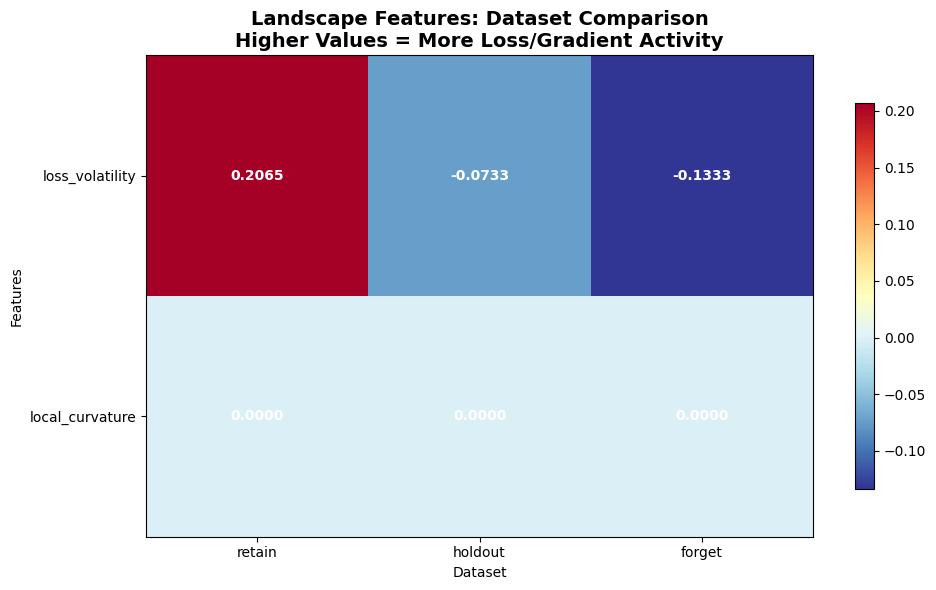

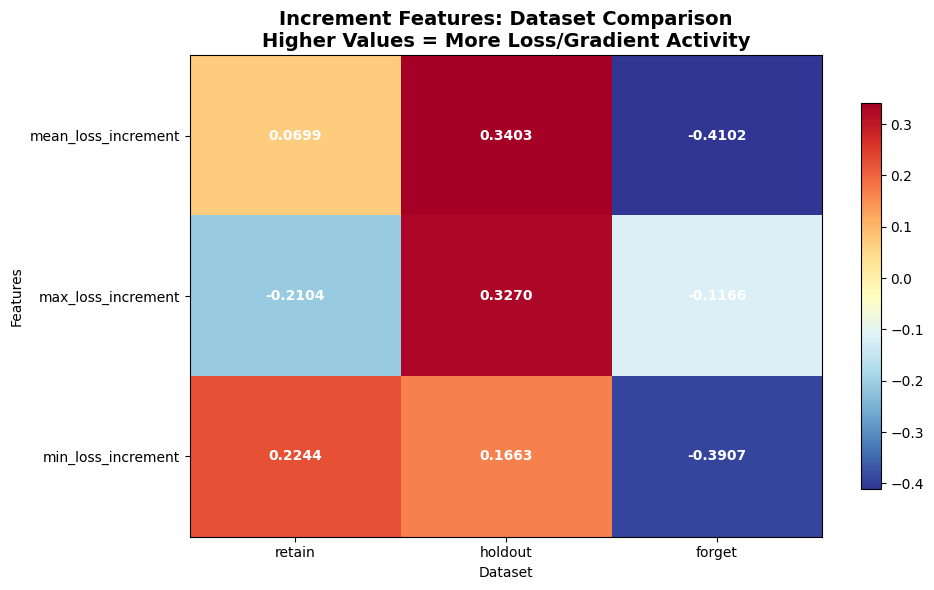

In [74]:
# Visualize ILL Category Analysis
def plot_ill_category_analysis(category_analysis):
    """
    Create comprehensive visualizations for ILL category analysis.
    """
    categories = list(category_analysis.keys())
    datasets = ['retain', 'holdout', 'forget']
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    # 1. Category-level means comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        category_means = []
        category_stds = []
        
        for dataset in datasets:
            if dataset in category_analysis[category]:
                category_means.append(category_analysis[category][dataset]['category_mean'])
                category_stds.append(category_analysis[category][dataset]['category_std'])
            else:
                category_means.append(0)
                category_stds.append(0)
        
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, category_means, yerr=category_stds, 
                     color=[colors[d] for d in datasets], alpha=0.7, capsize=5)
        
        ax.set_title(f'{category} Features\nMean Values Across Datasets', fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Mean Feature Value')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets)
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, category_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplot
    if len(categories) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_category_means.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # 2. Feature-level heatmap for each category
    for category in categories:
        if category not in category_analysis:
            continue
            
        # Get feature names for this category
        feature_names = None
        for dataset in datasets:
            if dataset in category_analysis[category]:
                feature_names = category_analysis[category][dataset]['feature_names']
                break
        
        if not feature_names:
            continue
            
        # Create data matrix
        data_matrix = []
        for feature_idx in range(len(feature_names)):
            row = []
            for dataset in datasets:
                if dataset in category_analysis[category]:
                    row.append(category_analysis[category][dataset]['mean_values'][feature_idx])
                else:
                    row.append(0)
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names)*0.8)))
        im = ax.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
        
        ax.set_title(f'{category} Features: Dataset Comparison\nHigher Values = More Loss/Gradient Activity', 
                    fontweight='bold', fontsize=14)
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Features')
        ax.set_xticks(range(len(datasets)))
        ax.set_yticks(range(len(feature_names)))
        ax.set_xticklabels(datasets)
        ax.set_yticklabels(feature_names)
        
        # Add text annotations
        for i in range(len(feature_names)):
            for j in range(len(datasets)):
                text = ax.text(j, i, f'{data_matrix[i, j]:.4f}',
                              ha="center", va="center", color="white", fontweight='bold')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.savefig(f'{plots_base_dir}/ill_{category.lower()}_features.png', bbox_inches='tight', dpi=150)
        plt.show()

# Plot ILL category analysis
plot_ill_category_analysis(category_analysis)

In [75]:
# Comprehensive TOFU ILL Discrimination Summary Report
def create_tofu_ill_discrimination_summary(ill_discrimination, boundary_results, pairwise_results, 
                                          best_discriminative_feature, feature_discrimination_scores):
    """
    Generate a comprehensive summary report for TOFU ILL-based dataset discrimination.
    """
    print("="*80)
    print("COMPREHENSIVE TOFU INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT")
    print("="*80)
    
    # Overall discrimination performance for machine unlearning
    print("\n1. MACHINE UNLEARNING DISCRIMINATION PERFORMANCE:")
    print("-" * 60)
    overall_cv = ill_discrimination['cv_scores'].mean()
    overall_std = ill_discrimination['cv_scores'].std()
    print(f"3-way classification (Forget/Retain/Holdout): {overall_cv:.3f} ± {overall_std:.3f}")
    
    print("\nClassifier comparison for TOFU datasets:")
    for clf_name, results in boundary_results.items():
        print(f"  {clf_name:15}: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    # Feature importance for unlearning
    print("\n2. MOST IMPORTANT ILL FEATURES FOR UNLEARNING:")
    print("-" * 60)
    top_features = ill_discrimination['feature_importance'].head(5)
    for idx, row in top_features.iterrows():
        print(f"{row['rank']}. {row['feature']:25}: {row['importance']:.4f}")
    
    # Unlearning-specific insights
    print("\n3. UNLEARNING INSIGHTS FROM PAIRWISE ANALYSIS:")
    print("-" * 60)
    for pair_name, results in pairwise_results.items():
        acc = results['classification_accuracy']
        std = results['classification_std']
        n_sig = len(results['significant_features'])
        
        if 'forget' in pair_name:
            interpretation = "🔍 Key for detecting what should be forgotten"
        elif 'retain_holdout' in pair_name:
            interpretation = "📊 Distinguishes training vs. evaluation data"
        else:
            interpretation = "🎯 General discrimination capability"
            
        print(f"{pair_name.replace('_', ' vs ').title():25}: {acc:.3f}±{std:.3f} - {interpretation}")
    
    # Best feature for unlearning
    print(f"\n4. TOP DISCRIMINATIVE FEATURE FOR MACHINE UNLEARNING:")
    print("-" * 60)
    print(f"🏆 Feature: {best_discriminative_feature}")
    print(f"   Effect size: {feature_discrimination_scores[best_discriminative_feature]:.3f}")
    print(f"   This feature is most effective for identifying data that should be 'forgotten'")
    
    # Practical recommendations
    print("\n5. RECOMMENDATIONS FOR TOFU UNLEARNING:")
    print("-" * 60)
    
    # Find which pair is easiest/hardest to distinguish
    forget_pairs = {k: v for k, v in pairwise_results.items() if 'forget' in k}
    best_forget_pair = max(forget_pairs.items(), key=lambda x: x[1]['classification_accuracy'])
    worst_forget_pair = min(forget_pairs.items(), key=lambda x: x[1]['classification_accuracy'])
    
    print(f"• Easiest to identify for forgetting: {best_forget_pair[0].replace('_', ' vs ')} ({best_forget_pair[1]['classification_accuracy']:.3f})")
    print(f"• Hardest to distinguish: {worst_forget_pair[0].replace('_', ' vs ')} ({worst_forget_pair[1]['classification_accuracy']:.3f})")
    print(f"• Focus on top features: {', '.join(top_features.head(3)['feature'].tolist())}")
    print(f"• Use {best_discriminative_feature} as primary unlearning indicator")
    
    # Save results
    import pickle
    comprehensive_tofu_results = {
        'discrimination_analysis': ill_discrimination,
        'boundary_analysis': boundary_results,
        'pairwise_analysis': pairwise_results,
        'best_discriminative_feature': best_discriminative_feature,
        'feature_discrimination_scores': feature_discrimination_scores,
        'dataset_type': 'TOFU',
        'unlearning_insights': {
            'best_forget_discrimination': best_forget_pair,
            'worst_forget_discrimination': worst_forget_pair,
            'top_features': top_features.to_dict('records')
        }
    }
    
    results_file = f'{plots_base_dir}/comprehensive_tofu_ill_discrimination_results.pkl'
    with open(results_file, 'wb') as f:
        pickle.dump(comprehensive_tofu_results, f)
    
    print(f"\n📁 Complete TOFU ILL results saved to: {results_file}")
    print("="*80)
    
    return comprehensive_tofu_results

# Generate the comprehensive TOFU summary
print("Generating comprehensive TOFU ILL discrimination summary...")
comprehensive_tofu_results = create_tofu_ill_discrimination_summary(
    ill_discrimination, boundary_results, pairwise_results, 
    best_discriminative_feature, feature_discrimination_scores
)

print("\n🎉 TOFU INPUT LOSS LANDSCAPE ANALYSIS COMPLETE!")
print("="*60)
print("📊 Generated comprehensive analysis for machine unlearning:")
print("   • Loss landscape feature discrimination")
print("   • Forget vs Retain vs Holdout classification")
print("   • Feature importance for unlearning scenarios")
print("   • Statistical distance analysis")
print("   • Manifold structure comparisons")
print("   • Specialized unlearning insights")
print("="*60)

Generating comprehensive TOFU ILL discrimination summary...
COMPREHENSIVE TOFU INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT

1. MACHINE UNLEARNING DISCRIMINATION PERFORMANCE:
------------------------------------------------------------
3-way classification (Forget/Retain/Holdout): 0.793 ± 0.043

Classifier comparison for TOFU datasets:
  Linear SVM     : 0.774 ± 0.049
  RBF SVM        : 0.770 ± 0.038
  Decision Tree  : 0.776 ± 0.030
  Naive Bayes    : 0.733 ± 0.055
  Random Forest  : 0.793 ± 0.041

2. MOST IMPORTANT ILL FEATURES FOR UNLEARNING:
------------------------------------------------------------
1. original_loss            : 0.4788
2. mean_neighbor_loss       : 0.1031
3. min_neighbor_loss        : 0.0957
4. max_neighbor_loss        : 0.0787
5. mean_loss_increment      : 0.0480

3. UNLEARNING INSIGHTS FROM PAIRWISE ANALYSIS:
------------------------------------------------------------
Forget Vs Vs Vs Retain   : 0.994±0.004 - 🔍 Key for detecting what should be forgotten
Forg